In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os
import matplotlib as mpl
import matplotlib.font_manager as fm
from scipy import stats

In [148]:
pd.set_option('display.max_columns', None)

In [149]:
df= pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\(아이엠뱅크) 2025 교육용 데이터.csv', encoding='cp949')
df_b = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\iM뱅크_금리현황_2022-2024.csv')
fee_df = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\추정비이자수익률.csv')

#df_c = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\iM뱅크_금리현황_2022-2024(post).csv')

In [150]:
# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [151]:
count_mapping = {
    "0건": 0,
    "1건": 1,
    "2건": 2,
    "2건초과 5건이하": 3.5,
    "5건초과 10건이하": 7.5,
    "10건초과 20건이하": 15,
    "20건초과 30건이하": 25,
    "30건초과 40건이하": 35,
    "40건초과 50건이하": 45,
    "50건 초과": 55,
}

channel_count_cols = [
    "인터넷뱅킹거래건수",
    "스마트뱅킹거래건수",
    "폰뱅킹거래건수",
    "자동이체거래건수",
    "창구거래건수",
    "ATM거래건수",
    "외환_수출실적거래건수",
    "외환_수입실적거래건수",
]

for col in channel_count_cols:
    if col in df.columns:
        df[col] = df[col].map(count_mapping)

account_mapping = {
    "0개": 0,
    "1개": 1,
    "2개": 2,
    "2개초과 5개이하": 4,
    "5개초과 10개이하": 8,
    "10개초과 20개이하": 15.5,
    "20개초과 30개이하": 25.5,
    "30개초과 40개이하": 35.5,
    "40개초과 50개이하": 45.5,
    "50개 초과": 55,
}

account_count_cols = [
    "요구불예금좌수",
    "거치식예금좌수",
    "적립식예금좌수",
    "수익증권좌수",
    "신탁좌수",
    "퇴직연금좌수",
    "여신_운전자금대출좌수",
    "여신_시설자금대출좌수",
    "신용카드개수",
]

for col in account_count_cols:
    if col in df.columns:
        df[col] = df[col].map(account_mapping)

In [152]:
# 1. 자산성 지표 (Asset)
# 근거: 법인의 현금 동원력과 재무 안정성을 나타냄. 
# 단순히 합치지 않고 '요구불(유동성)'과 '장기저축성'을 묶어 법인의 자금 성격을 파악.
deposit_bal_cols = ["요구불예금잔액", "거치식예금잔액", "적립식예금잔액"]  
product_bal_cols = ["수익증권잔액", "신탁잔액"]  # 신탁과 퇴직연금 corr = .92로 퇴직연금을 포함하는 신탁만 사용
deposit_cnt_cols = ["요구불예금좌수", "거치식예금좌수", "적립식예금좌수"]  
product_cnt_cols = ["수익증권좌수", "신탁좌수", "퇴직연금좌수"]  
flow_cols = ["요구불입금금액", "요구불출금금액"]

# 2. 여신(대출) 지표 (Debt)
# 근거: 운전자금(운영비)과 시설자금(투자)을 구분. 
# 시설자금 비중이 높으면 공장이나 설비를 가진 '제조/생산형 법인'일 확률이 매우 높음.
loan_bal_cols = ["여신_운전자금대출잔액", "여신_시설자금대출잔액"]  
loan_cnt_cols = ["여신_운전자금대출좌수", "여신_시설자금대출좌수"]
 
# 3. 영업 거래 지표 (Transaction)
# 근거: 창구 거래가 많으면 '전통적/오프라인', 스마트뱅킹이 많으면 '젊은/온라인' 기업.
# 자동이체와 카드 사용액은 기업의 활동성을 대변함.

rjfo_total = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액', '창구거래금액', 'ATM거래금액']
rjfo_digital = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액']
rjfo_offline = ['창구거래금액', 'ATM거래금액']

rjfo_card_total = ['신용카드사용금액', '체크카드사용금액']

channel_cnt_cols = [  
   "창구거래건수",  
   "인터넷뱅킹거래건수",  
   "스마트뱅킹거래건수",  
   "폰뱅킹거래건수",  
   "ATM거래건수",  
]

# 4. 대외 무역 지표 (Global)
# 근거: 수출입 실적은 공단 지역(달성군, 북구 등) 보간의 결정적 근거.
dhlghks = ['외환_수출실적금액', '외환_수입실적금액']



In [153]:
# 피처 생성
df['총예금잔액'] = df[deposit_bal_cols].sum(axis=1)
df['자산관리잔액'] = df[product_bal_cols].sum(axis=1)
df['총대출잔액'] = df[loan_bal_cols].sum(axis=1)
df['총예금좌수'] = df[deposit_cnt_cols].sum(axis=1)
df['총대출좌수'] = df[loan_cnt_cols].sum(axis=1)
df['자산관리좌수']= df[product_cnt_cols].sum(axis=1)
df['총요구불입출금'] = df[flow_cols].sum(axis=1)

df['전체거래액'] = df[rjfo_total].sum(axis=1)
df['총디지털거래액'] = df[rjfo_digital].sum(axis=1)
df['총오프라인거래액'] = df[rjfo_offline].sum(axis=1)
df['총카드소비'] = df[rjfo_card_total].sum(axis=1)

df['총외환실적'] = df[dhlghks].sum(axis=1)


In [154]:
# 2. 필요한 컬럼만 선택 (기준년월, 평균대출금리, 평균예금금리, 예대마진)
# 만약 엑셀의 열 이름이 정확히 일치하지 않는다면 엑셀에 적힌 실제 이름으로 수정해야 합니다.
cols_to_use = ['기준년월', '평균대출금리(%)', '평균예금금리(%)', '예대마진(%)']
df_b_subset = df_b[cols_to_use]

# 3. 기존 데이터(a)와 병합 (Left Join)
# df_a는 이미 파이썬에서 작업 중인 데이터프레임이라고 가정합니다.
df2 = pd.merge(df, df_b_subset, on='기준년월', how='left')


In [155]:
fee_df.columns = fee_df.columns.str.strip() # 컬럼명 공백 제거

# 2. 에러 방지: df2에 이미 수수료율 관련 컬럼이 있다면 미리 삭제
target_fee_cols = ['신탁보수율(trust)', '카드수수료율(card)', '수익증권/연금(fund)', '외환/기타(fx)', '채널건당(channel)', '연도(year)']
df2 = df2.drop(columns=[c for c in target_fee_cols if c in df2.columns])

# 3. 기준년월 처리 및 연도 키 생성
# '기준년월'이 202201(숫자) 형태라면 // 100을, 문자열이라면 앞 4글자를 사용합니다.
try:
    df2['연도_join'] = (df2['기준년월'].astype(int) // 100)
except:
    df2['연도_join'] = df2['기준년월'].astype(str).str[:4].astype(int)

# 4. 데이터 병합 (how='left'로 원본 데이터 유지)
df2 = pd.merge(df2, fee_df, left_on='연도_join', right_on='연도(year)', how='left')

# 5. 단위 환산 및 수익 계산
# df2의 금액 컬럼들: 백만원 단위
# 수수료율: 소수점 형태 (예: 0.004) -> 결과도 백만원 단위
# 채널건당: 300원 -> 백만원 단위로 변환 필요 (300 / 1,000,000)

# (1) 수익증권수익
df2['수익증권수익'] = df2['수익증권잔액'] * df2['수익증권/연금(fund)']

# (2) 신탁수익
df2['신탁수익'] = df2['신탁잔액'] * df2['신탁보수율(trust)']

# (3) 퇴직연금수익
# df2['퇴직연금수익'] = df2['퇴직연금잔액'] * df2['수익증권/연금(fund)']

# (4) 외환수익
df2['외환수익'] = (df2['외환_수출실적금액'] + df2['외환_수입실적금액']) * df2['외환/기타(fx)']

# (5) 카드수익a
df2['카드수익'] = (df2['신용카드사용금액'] + df2['체크카드사용금액']) * df2['카드수수료율(card)']

# 창구 수수료 및 이체 수수료는 현재 수익성에 큰 의미가 없음 -> 해당 비이자수익은 제외

# 6. 최종 추정 비이자수익 합산 (결과 단위: 백만원)
df2['추정_비이자수익'] = (
    df2['수익증권수익'].fillna(0) +
    df2['신탁수익'].fillna(0) +
    df2['외환수익'].fillna(0) +
    df2['카드수익'].fillna(0)
)

# 7. 임시 컬럼 정리
df2 = df2.drop(columns=['연도_join', '연도(year)'])

# 확인
print(df2[['기준년월', '추정_비이자수익']].head(10))

     기준년월  추정_비이자수익
0  202412  0.000000
1  202412  0.000000
2  202412  0.000293
3  202412  0.000000
4  202412  0.032034
5  202412  0.000000
6  202412  0.001227
7  202412  0.027720
8  202412  0.000548
9  202412  0.001510


In [156]:
# 4. 변수 추가+ 결과 확인
df2['총자산']= (df2['총예금잔액']+df2['총대출잔액']+df2['자산관리잔액'])
df2['예금이자']=(df2['총예금잔액']*df2['평균예금금리(%)']*0.01)
df2['대출이자']=(df2['총대출잔액']*df2['평균대출금리(%)']*0.01)
df2['예대마진']=df2['대출이자']-df2['예금이자']

# 예대마진수익률(%)과, 자산대비수익률(%) 두 변수 모두 분모가 총자산인데,
# 총자산이 0원이란것은 기업활동이 멈췄다고 생각할 수 있음.
# 파이썬은 분자=0 , return 0 / 분모=0, return = nan or inf
# 우리는 활동성과 수익성이 좋은 중소기업을 발굴해내는것이 목표이기에 분리(휴면기업으로) 해서 분석하는것이 좋아보임

df2['예대마진수익률(%)']=(df2['대출이자']-df2['예금이자'])/(df2['총자산'])*100
# df2['추정_비이자수익']
df2['이자+비이자수익']=df2['예대마진']+df2['추정_비이자수익']
df2['자산대비수익률(%)']=df2['이자+비이자수익']/df2['총자산']*100

print(df2.head())

     기준년월 업종_대분류  업종_중분류 사업장_시도 사업장_시군구 법인_고객등급 전담고객여부  요구불예금잔액  거치식예금잔액  \
0  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.16      0.0   
1  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.03      0.0   
2  202412    건설업  종합 건설업  대전광역시      서구      우수      N     0.24      0.0   
3  202412    건설업  종합 건설업  대구광역시      서구      우수      Y   180.00      0.0   
4  202412    건설업  종합 건설업  대구광역시      서구      우수      Y    41.00      0.0   

   적립식예금잔액  수익증권잔액   신탁잔액  퇴직연금잔액  여신한도금액  여신_운전자금대출잔액  여신_시설자금대출잔액  \
0      0.0     0.0    0.0     0.0     0.0         70.0          0.0   
1      0.0     0.0    0.0     0.0     0.0          1.2          0.0   
2      0.0     0.0    0.0     0.0   680.0        430.0          0.0   
3      0.0     0.0    0.0     0.0     0.0       3400.0          0.0   
4      0.0     0.0  120.0   120.0   170.0          0.0          0.0   

   외환_수출실적금액  외환_수입실적금액  신용카드사용금액  체크카드사용금액  창구거래금액  인터넷뱅킹거래금액  스마트뱅킹거래금액  \
0        0.0        0.0      0.00      

In [157]:
# 1. 세종특별자치시인 경우 시군구를 '세종시'로 자동 채우기
# (이미 시도가 세종시로 되어 있는 데이터들 중 시군구가 Null인 경우를 해결)
df2.loc[df2['사업장_시도'] == '세종특별자치시', '사업장_시군구'] = '세종시'

# 2. 나머지 모든 '사업장_시도'와 '사업장_시군구'의 Null값을 '미상'으로 일괄 변경
df2['사업장_시도'] = df2['사업장_시도'].fillna('미상')
df2['사업장_시군구'] = df2['사업장_시군구'].fillna('미상')

# 3. 결과 확인
print("=== [결측치 처리 후 지역 분포 확인] ===")
print(df2['사업장_시도'].value_counts().head(10))

# 4. 세종시 보정 결과 확인
sejong_check = df2[df2['사업장_시도'] == '세종특별자치시']['사업장_시군구'].unique()
print(f"\n세종시 내 시군구 리스트: {sejong_check}")

=== [결측치 처리 후 지역 분포 확인] ===
사업장_시도
대구광역시    153267
경상북도     116072
미상        16993
서울특별시     16477
부산광역시     16172
경상남도      10845
경기도        9734
울산광역시      3245
인천광역시      2953
대전광역시      1218
Name: count, dtype: int64

세종시 내 시군구 리스트: ['세종시']


In [158]:
# 딕셔너리 형태로 깔끔하게 변경
df2 = df2.rename(columns={
    '평균대출금리(%)': '월평균대출금리(%)',
    '평균예금금리(%)': '월평균예금금리(%)',
    '예대마진(%)':'기준예대마진(%)',
    '이자+비이자수익' : '총수익',
    '예금이자': '기준예금이자',
    '대출이자':'기준대출이자'
})

In [159]:
# 1. 예대마진이 0인 행만 추출
margin_zero = df2[df2['예대마진'] == 0].copy()

# 2. 둘 다 0인 경우
case_both_zero = margin_zero[
    (margin_zero['기준대출이자'] == 0) & (margin_zero['기준예금이자'] == 0)
].copy()

# 3. 둘 다 0은 아닌데, 값이 같아서 0이 된 경우
case_equal_nonzero = margin_zero[
    (margin_zero['기준대출이자'] != 0) &
    (margin_zero['기준예금이자'] != 0) &
    (margin_zero['기준대출이자'] == margin_zero['기준예금이자'])
].copy()

print(f"예대마진이 0인 전체 건수: {len(margin_zero):,}건")
print(f"대출이자=0, 예금이자=0 인 건수: {len(case_both_zero):,}건")
print(f"둘 다 0은 아니지만 대출이자=예금이자 인 건수: {len(case_equal_nonzero):,}건")

예대마진이 0인 전체 건수: 1,984건
대출이자=0, 예금이자=0 인 건수: 1,947건
둘 다 0은 아니지만 대출이자=예금이자 인 건수: 37건


In [160]:
df2.shape

(347299, 77)

In [161]:
df2 = df2[df2['총자산'] != 0].copy()
# 총자산 ==0인것은 휴면고객으로 분류해서 진행

In [162]:
df2.shape

(345553, 77)

# 활동성 지수

## 금융활동성지수 계산

위에서 생성한 기존 파생변수는 그대로 유지하고, 이 아래에서 활동성지수 계산에 필요한 변수만 추가합니다.

활동성지수는 다음 3개 축으로 계산합니다.
- 규모점수
- 빈도점수
- 다양성점수


In [17]:
# 활동성지수 계산용 추가 변수
# 기존 파생변수는 유지하고, 활동성 계산에 필요한 명시적 변수만 추가한다.
df2['총채널거래금액'] = df2['전체거래액']
df2['총채널거래건수'] = df2[channel_cnt_cols].sum(axis=1)
df2['총거래건수'] = df2['총채널거래건수'] + df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총디지털거래건수'] = df2[['인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수']].sum(axis=1)
df2['디지털거래건수비중'] = np.where(
    df2['총거래건수'] > 0,
    df2['총디지털거래건수'] / df2['총거래건수'],
    0
)
df2['총외환금액'] = df2['총외환실적']
df2['총외환거래건수'] = df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총카드사용금액'] = df2['총카드소비']

df2['예금이용'] = (df2['총예금잔액'] > 0).astype(int)
df2['대출이용'] = (df2['총대출잔액'] > 0).astype(int)
df2['카드이용'] = (df2['총카드사용금액'] > 0).astype(int)
df2['외환이용'] = (df2['총외환금액'] > 0).astype(int)
df2['상품다양성개수'] = df2[['예금이용', '대출이용', '카드이용', '외환이용']].sum(axis=1)
df2['다양성점수'] = df2['상품다양성개수'] / 4

df2[['총채널거래금액', '총채널거래건수', '총거래건수', '총디지털거래건수', '디지털거래건수비중', '총외환금액', '총외환거래건수', '총카드사용금액', '상품다양성개수', '다양성점수']].head()


,총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,상품다양성개수,다양성점수
0,10.0,3.5,3.5,3.5,1.000000,0.0,0.0,0.00,2,0.50
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00,2,0.50
2,370.0,55.0,55.0,55.0,1.000000,0.0,0.0,0.31,3,0.75
3,82.0,28.5,28.5,25.0,0.877193,0.0,0.0,0.00,2,0.50
4,33.0,16.0,16.0,15.0,0.937500,0.0,0.0,1.90,2,0.50


In [18]:
a= df2[df2['총외환금액'] >= 1]

In [19]:
a['총외환금액'].value_counts().sort_values()

총외환금액
2.68      1
7.06      1
1.78      1
14.80     1
2.57      1
         ..
1.40     44
1.30     60
1.00     65
1.20     72
1.10     85
Name: count, Length: 533, dtype: int64

(array([459., 283., 216., 175., 131., 101.,  67.,  43.,  41.,  28.,  30.,
         37.,  19.,  29.,  17.,  30.,  20.,   8.,  10.,   8.,   9.,  10.,
         11.,   3.,   2.,  12.,   2.,  14.,   2.,   3.,  16.,   3.,   8.,
          3.,   1.,  11.,   5.,   7.,   1.,   2.,   3.,   0.,   5.,   1.,
          0.,   6.,   0.,   1.,   0.,   1.,   1.,   3.,   3.,   2.,   0.,
          2.,   1.,   2.,   1.,   1.,   0.,   1.,   2.,   1.,   1.,   1.,
          1.,   5.,   1.,   0.,   1.,   0.,   2.,   0.,   1.,   1.,   0.,
          1.,   0.,   1.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   2.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   2.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0., 

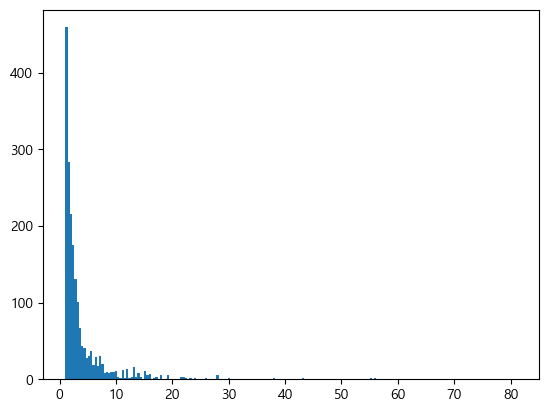

In [20]:
plt.hist(x='총외환금액',data=a, bins=200)

In [21]:
a['총외환금액'].quantile(1)

np.float64(81.0)

In [22]:
a['총외환거래건수'].describe()

count    1949.000000
mean       15.119292
std        15.360947
min         0.000000
25%         3.500000
50%         8.500000
75%        18.500000
max        70.000000
Name: 총외환거래건수, dtype: float64

In [23]:
a['총외환금액'].describe()

count    1949.000000
mean        4.268969
std         6.479664
min         1.000000
25%         1.400000
50%         2.200000
75%         4.100000
max        81.000000
Name: 총외환금액, dtype: float64

In [24]:
df2.describe().round(2)

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,월평균대출금리(%),월평균예금금리(%),기준예대마진(%),신탁보수율(trust),카드수수료율(card),수익증권/연금(fund),외환/기타(fx),채널건당(channel),수익증권수익,신탁수익,외환수익,카드수익,추정_비이자수익,총자산,기준예금이자,기준대출이자,예대마진,예대마진수익률(%),총수익,자산대비수익률(%),총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,예금이용,대출이용,카드이용,외환이용,상품다양성개수,다양성점수
count,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.0,345553.0,345553.0,345553.0,345553.0,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.00,345553.0,345553.00,345553.00,345553.00,345553.00,345553.00
mean,202306.93,162.86,613.65,3.91,0.84,234.28,80.01,633.53,827.36,810.60,0.02,0.02,5.98,0.16,255.52,799.71,13.52,3.00,104.81,195.51,901.48,1149.21,3.76,0.21,0.14,0.04,0.32,0.24,4.89,0.69,4.33,0.13,0.12,1.75,20.92,2.88,0.57,1.93,17.20,780.42,235.12,1637.95,4.10,5.57,0.59,2050.69,1176.56,816.23,360.33,6.13,0.03,0.43,0.27,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.06,0.00,0.01,0.07,2653.50,2.16,7.01,4.85,0.30,4.92,0.32,1176.56,28.05,28.30,24.37,0.67,0.03,0.25,6.13,0.9,0.93,0.64,0.05,2.51,0.63
std,81.71,2447.92,40405.88,40.83,22.73,5583.80,890.66,4825.43,3896.29,3819.33,0.40,0.39,113.16,2.59,18792.89,25307.12,135.30,38.85,1961.48,4097.00,22152.70,29381.18,4.59,1.85,0.77,0.36,0.84,0.48,9.43,1.41,5.96,1.54,1.00,6.43,22.63,8.61,3.69,6.14,14.95,40518.62,5583.89,5667.29,5.28,9.67,1.30,48595.32,35017.82,25311.61,18960.08,113.26,0.58,0.05,0.05,0.02,0.0,0.0,0.0,0.0,0.0,0.01,1.49,0.00,0.11,1.50,42927.73,118.10,24.59,113.94,0.21,113.94,1.08,35017.82,30.29,30.65,26.03,0.42,0.58,1.99,113.26,0.3,0.26,0.48,0.22,0.68,0.17
min,202201.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.29,0.15,0.11,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,-19204.15,-0.35,-19204.15,-0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,202210.00,0.36,0.00,0.00,0.00,0.00,0.00,0.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.50,6.00,8.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.50,0.43,0.00,68.00,1.00,1.00,0.00,16.10,1.10,0.00,0.00,0.00,0.00,0.41,0.27,0.14,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,114.00,0.00,0.28,0.19,0.26,0.20,0.27,1.10,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.0,1.00,0.00,0.00,2.00,0.50
50%,202307.00,6.80,0.00,0.00,0.00,0.00,0.00,0.00,150.00,0.00,0.00,0.00,1.10,0.00,0.00,29.00,0.00,0.00,0.00,9.60,57.00,63.00,2.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,7.50,0.00,0.00,0.00,15.00,8.30,0.00,330.00,2.00,2.00,0.00,126.00,53.17,39.50,0.00,1.10,0.00,0.44,0.29,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,460.00,0.02,1.41,1.24,0.39,1.26,0.39,53.17,16.00,16.00,15.00,0.94,0.00,0.00,1.10,1.0,1.00,1.00,0.00,3.00,0.75
75%,202404.00,56.00,0.00,0.00,0.00,0.00,0.00,190.00,530.00,350.00,0.00,0.00,4.60,0.00,0.14,180.00,0.66,0.00,0.30,30.00,250.00,2

In [25]:
key_vars = ['총자산', '여신한도금액', '전체거래액', '총수익']
# 총외환수익 = 0이 약 30만개정도이고, 이외의 값을 모두 이상치로 처리하기에 변별력이 큰 변수가 아님을 확인
# > 이는 활동성지표에서 외환여부(0/1)로 표현하여 활동성을 대변하는 지표로 활용할 수 있도록 함

# 총외환수익과 예대의 크기에관한 이야기는 활동성에서 규모로 다루기로함.

In [26]:
# df2는 일반 고객용 데이터프레임
# key_vars는 분석가가 선정한 핵심 변수 이름 리스트 (예: ['총자산', '전체거래액', ...])

# 이상치(VVVIP)를 판단할 조건 시리즈 (초기값: 모두 False)
is_vvvip_condition = pd.Series([False] * len(df2))

for var in key_vars:
    # IQR 계산
    Q1 = df2[var].quantile(0.25)
    Q3 = df2[var].quantile(0.75)
    IQR = Q3 - Q1
    
    # 상하단 커트라인 설정 (3.0은 아주 극단적인 값만!)
    upper_whisker = Q3 + 3.0 * IQR
    lower_whisker = Q1 - 3.0 * IQR
    
    # 양수 쪽 이상치 OR 음수 쪽 이상치 하나라도 해당하면 VVVIP
    is_vvvip_condition = is_vvvip_condition | (df2[var] > upper_whisker) | (df2[var] < lower_whisker)

# 데이터 분리
vvvip_df2 = df2[is_vvvip_condition].copy()
analysis_df2 = df2[~is_vvvip_condition].copy()

print(f"상단/하단 이상치 포함 VVVIP: {len(vvvip_df2)}명")

C:\Users\campus4D059\AppData\Local\Temp\ipykernel_10520\605407364.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vvvip_df2 = df2[is_vvvip_condition].copy()
C:\Users\campus4D059\AppData\Local\Temp\ipykernel_10520\605407364.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  analysis_df2 = df2[~is_vvvip_condition].copy()


상단/하단 이상치 포함 VVVIP: 60393명


In [27]:
vvvip_df2.describe().round(2)

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,월평균대출금리(%),월평균예금금리(%),기준예대마진(%),신탁보수율(trust),카드수수료율(card),수익증권/연금(fund),외환/기타(fx),채널건당(channel),수익증권수익,신탁수익,외환수익,카드수익,추정_비이자수익,총자산,기준예금이자,기준대출이자,예대마진,예대마진수익률(%),총수익,자산대비수익률(%),총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,예금이용,대출이용,카드이용,외환이용,상품다양성개수,다양성점수
count,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.0,60393.0,60393.0,60393.0,60393.0,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.00,60393.0,60393.0,60393.00,60393.00,60393.00,60393.00
mean,202306.50,666.94,3465.59,12.89,2.57,1195.17,347.14,3280.04,3168.94,3331.55,0.08,0.07,17.33,0.31,1412.86,4111.14,38.48,8.01,566.78,990.68,4544.52,5955.21,5.17,0.72,0.24,0.06,0.68,0.46,9.48,1.62,7.09,0.49,0.37,4.28,28.90,4.12,0.97,4.87,24.59,4145.42,1197.74,6500.48,6.13,11.10,1.21,10499.72,6137.28,4157.63,1979.65,17.64,0.15,0.43,0.28,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.32,0.00,0.02,0.34,11843.64,11.49,27.93,16.44,0.28,16.77,0.29,6137.28,43.14,44.01,34.00,0.68,0.15,0.86,17.64,0.9,0.9,0.69,0.13,2.61,0.65
std,81.25,5818.45,96600.91,87.23,49.12,13308.31,2089.61,11164.64,8878.36,8579.16,0.92,0.93,269.37,5.46,44934.98,60424.49,310.59,79.61,4663.46,9758.49,52835.77,70079.78,6.91,4.14,1.14,0.46,1.53,0.61,15.06,2.27,9.01,3.19,1.85,10.58,24.14,10.96,4.91,10.87,19.16,96850.02,13308.34,12310.45,8.68,15.28,1.98,115865.16,83584.47,60433.14,45317.81,269.56,1.36,0.05,0.05,0.02,0.0,0.0,0.0,0.0,0.0,0.02,3.55,0.00,0.25,3.58,102164.21,282.30,53.54,272.13,0.22,272.12,0.47,83584.47,38.51,39.47,29.89,0.37,1.36,4.04,269.56,0.3,0.3,0.46,0.33,0.80,0.20
min,202201.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.29,0.15,0.11,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,-19204.15,-0.35,-19204.15,-0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00
25%,202210.00,2.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.10,0.00,0.00,0.00,19.00,86.00,97.00,2.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,7.50,3.90,0.00,910.00,2.00,2.00,0.00,202.00,58.00,21.40,0.00,0.00,0.00,0.41,0.27,0.14,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.00,1522.00,0.01,3.76,2.72,0.22,2.87,0.23,58.00,7.50,7.50,3.50,0.46,0.00,0.00,0.00,1.0,1.0,0.00,0.00,2.00,0.50
50%,202307.00,42.00,0.00,0.00,0.00,0.00,0.00,900.00,750.00,490.00,0.00,0.00,2.60,0.00,0.00,290.00,0.00,0.00,0.00,48.00,620.00,670.00,4.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,4.00,0.00,0.00,0.00,25.00,0.00,0.00,0.00,15.00,63.00,0.00,3500.00,4.00,4.00,0.00,1360.00,605.00,328.30,5.00,2.60,0.00,0.44,0.29,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.00,0.00,0.01,4430.00,0.17,14.70,13.39,0.37,13.61,0.37,605.00,45.00,45.00,35.00,0.88,0.00,0.00,2.60,1.0,1.0,1.00,0.00,3.00,0.75
75%,202403.00,250.00,0.00,0.00,0.00,170.00,110.00,2100.00,2600.00,4100.00,0.00,0.00,8.90,0.00,30.00,1200.00,3.10,0.00,12.00,180.00,1700.00,1700.00,8.00,0.

In [28]:
analysis_df2['자산관리잔액'].value_counts()

자산관리잔액
0.00      233896
120.00      1161
110.00      1114
130.00      1008
100.00       795
           ...  
23.20          1
162.00         1
70.40          1
564.00         1
65.71          1
Name: count, Length: 1005, dtype: int64

In [29]:
analysis_df2.describe().round(2)

,기준년월,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,월평균대출금리(%),월평균예금금리(%),기준예대마진(%),신탁보수율(trust),카드수수료율(card),수익증권/연금(fund),외환/기타(fx),채널건당(channel),수익증권수익,신탁수익,외환수익,카드수익,추정_비이자수익,총자산,기준예금이자,기준대출이자,예대마진,예대마진수익률(%),총수익,자산대비수익률(%),총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,예금이용,대출이용,카드이용,외환이용,상품다양성개수,다양성점수
count,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.0,285160.0,285160.0,285160.0,285160.0,285160.00,285160.00,285160.0,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.00,285160.0,285160.00,285160.00,285160.00,285160.00,285160.00
mean,202307.03,56.11,9.65,2.00,0.48,30.78,23.44,73.04,331.44,276.69,0.00,0.00,3.57,0.13,10.41,98.39,8.24,1.94,6.97,27.10,129.94,131.36,3.46,0.10,0.11,0.03,0.24,0.19,3.92,0.49,3.74,0.05,0.07,1.21,19.23,2.62,0.48,1.31,15.63,67.76,31.25,608.14,3.67,4.40,0.46,261.30,125.95,108.57,17.38,3.70,0.01,0.43,0.27,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.01,0.0,0.00,0.01,707.15,0.19,2.58,2.40,0.30,2.41,0.32,125.95,24.86,24.97,22.33,0.66,0.01,0.12,3.70,0.9,0.93,0.62,0.04,2.49,0.62
std,81.80,162.54,98.91,19.71,10.69,189.53,134.96,141.55,543.26,676.73,0.11,0.06,10.81,1.36,55.89,168.32,39.93,21.93,40.12,101.64,222.81,213.59,3.87,0.66,0.66,0.33,0.57,0.43,7.36,1.05,4.89,0.83,0.69,4.98,21.93,8.00,3.37,4.30,13.39,203.81,190.18,870.12,4.09,7.48,1.05,426.37,195.69,176.34,70.72,11.08,0.13,0.05,0.05,0.02,0.0,0.0,0.0,0.0,0.0,0.00,0.05,0.0,0.01,0.05,946.63,0.57,3.70,3.69,0.20,3.70,1.17,195.69,27.18,27.30,24.66,0.43,0.13,1.11,11.08,0.3,0.25,0.48,0.19,0.66,0.16
min,202201.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.29,0.15,0.11,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.0,0.00,0.00,0.01,0.00,0.00,-14.35,-0.35,-14.00,-0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,202210.00,0.28,0.00,0.00,0.00,0.00,0.00,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,4.00,5.50,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.50,0.32,0.00,50.00,1.00,1.00,0.00,11.30,0.31,0.00,0.00,0.00,0.00,0.41,0.27,0.14,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.0,0.00,0.00,91.60,0.00,0.22,0.16,0.27,0.17,0.27,0.31,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.0,1.00,0.00,0.00,2.00,0.50
50%,202307.00,4.80,0.00,0.00,0.00,0.00,0.00,0.00,120.00,0.00,0.00,0.00,0.86,0.00,0.00,18.00,0.00,0.00,0.00,7.20,37.00,43.00,2.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,7.50,0.00,0.00,0.00,15.00,5.60,0.00,250.00,2.00,2.00,0.00,84.00,36.00,27.00,0.00,0.88,0.00,0.44,0.29,0.15,0.0,0.0,0.0,0.0,300.0,0.00,0.00,0.0,0.00,0.00,311.00,0.02,1.02,0.90,0.39,0.91,0.39,36.00,15.00,15.00,15.00,0.94,0.00,0.00,0.88,1.0,1.00,1.00,0.00,3.00,0.75
75%,202404.00,39.00,0.00,0.00,0.00,0.00,0.00,100.00,400.00,70.00,0.00,0.00,4.00,0.00,0.00,120.00,0.47,0.00,0.08,20.00,160.00,170.00,4.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,4.00,0.00,0.00,0.00,45.00,1.00,0.00,1

1. 왜 이자+비이자수익(절대값)을 따로 봐야 할까?  
은행 입장에서 VVVIP는 **'우리한테 실제로 얼마를 벌어다 주느냐'**라는 **규모(Scale)**가 제일 중요해.  
  
A기업: 총자산 10조, 수익 1,000억 → 자산대비수익률(ROA) 1%    
B기업: 총자산 1억, 수익 5,000만 원 → 자산대비수익률(ROA) 50% 

# 지수변수 생성 전 vif확인

In [30]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [32]:
analysis_df2['총외환금액'].value_counts().sort_index()

총외환금액
0.00     274920
0.01       1626
0.02       1187
0.03        967
0.04        722
          ...  
12.00         5
13.00         1
14.00         2
15.00         2
19.00         1
Name: count, Length: 238, dtype: int64

In [163]:
analysis_df2.shape

(285160, 110)

In [33]:
# 1. 컬럼 생략 없이 다 보여줘! (None이 무제한이라는 뜻)
pd.set_option('display.max_columns', None)

print(df2.isnull().sum().sort_values())

기준년월       0
업종_대분류     0
업종_중분류     0
사업장_시도     0
사업장_시군구    0
          ..
대출이용       0
카드이용       0
외환이용       0
상품다양성개수    0
다양성점수      0
Length: 91, dtype: int64


In [34]:
# 1. 주희가 선정한 후보 변수 리스트 (활동성 + 수익성)
# 원본 데이터로 먼저 확인해서 '진짜 겹치는 놈'들을 잡아내자!
# 활동성 지표
vif_features1 = [
    '총예금잔액', '총대출잔액', '총채널거래금액', '총외환금액', '총카드사용금액', # 활동성-규모
    '총채널거래건수', '총외환거래건수', # 활동성-빈도
    '다양성점수' # 활동성 - 다양성
]

# 수익성 지표
vif_features2 = [
    '예대마진', '추정_비이자수익', '자산대비수익률(%)' # 수익성
]

# 검사용 데이터셋 생성 ( nan존재 시 연산불가 )
vif_data1 = analysis_df2[vif_features1]
vif_data2 = analysis_df2[vif_features2]

# 2. VIF 계산 수행
# 활동성
vif_df1 = pd.DataFrame()
vif_df1["Feature"] = vif_data1.columns
vif_df1["VIF"] = [variance_inflation_factor(vif_data1.values, i) for i in range(vif_data1.shape[1])]
# 수익성
vif_df2 = pd.DataFrame()
vif_df2["Feature"] = vif_data2.columns
vif_df2["VIF"] = [variance_inflation_factor(vif_data2.values, i) for i in range(vif_data2.shape[1])]

# 3. 결과 확인 (높은 순 정렬)
print("=== 알짜발굴단 활동성 변수 VIF 결과 ===")
print(vif_df1.sort_values(by="VIF", ascending=False))
print(f' ')
print("=== 알짜발굴단 수익성 변수 VIF 결과 ===")
print(vif_df2.sort_values(by="VIF", ascending=False))

=== 알짜발굴단 활동성 변수 VIF 결과 ===
   Feature       VIF
5  총채널거래건수  3.116054
7    다양성점수  2.620641
2  총채널거래금액  2.451479
6  총외환거래건수  1.671215
3    총외환금액  1.630431
1    총대출잔액  1.562623
0    총예금잔액  1.233569
4  총카드사용금액  1.181599
 
=== 알짜발굴단 수익성 변수 VIF 결과 ===
      Feature       VIF
0        예대마진  1.058992
2  자산대비수익률(%)  1.035692
1    추정_비이자수익  1.024039


### 셀 설명: 활동성지수 계산용 스케일러

금액·건수 변수는 단위와 분포가 매우 다르기 때문에, `log1p` 변환 후 정규화가 필요합니다. 여기서는 기본적으로 `MinMaxScaler`를 사용해 0~1 범위로 맞춥니다.


In [35]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

[총채널거래건수 통계치]
평균: 24.86 | 중앙값: 15.00 | 최빈값: 0.00


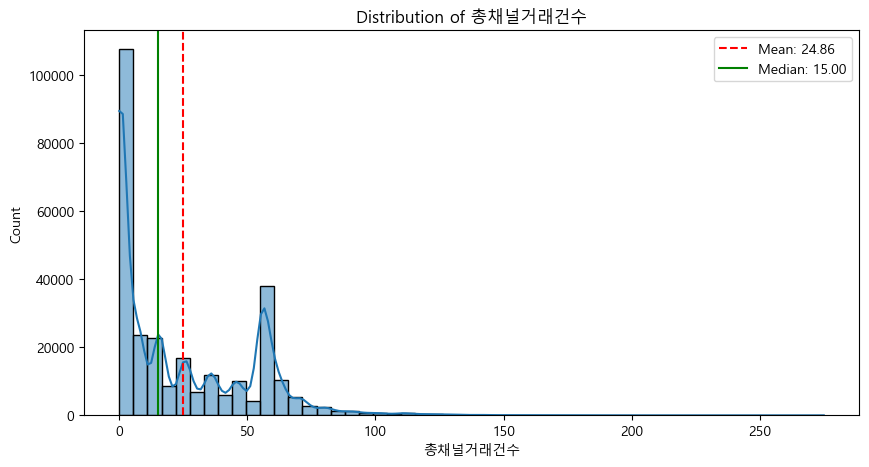

[총채널거래건수_log 통계치]
평균: 2.33 | 중앙값: 2.77 | 최빈값: 0.00


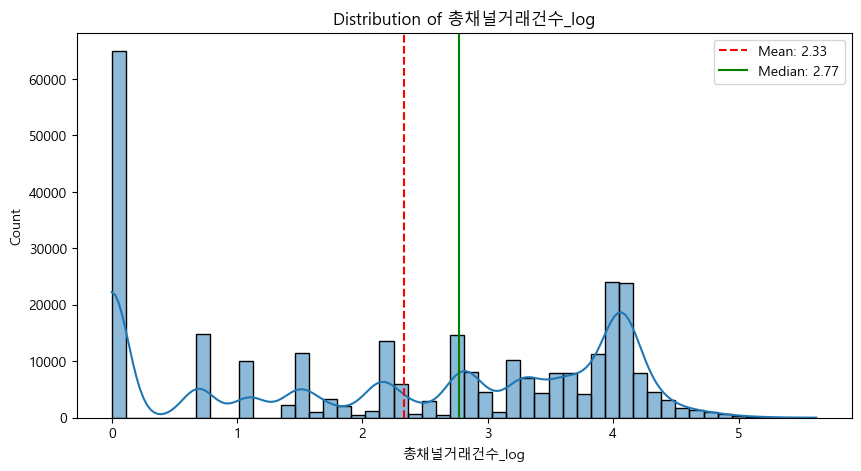

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def check_distribution(df, col):
    # 기초통계량 계산
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0] # 최빈값
    
    print(f"[{col} 통계치]")
    print(f"평균: {mean_val:,.2f} | 중앙값: {median_val:,.2f} | 최빈값: {mode_val:,.2f}")
    
    # 히스토그램 시각화
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=50)
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:,.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:,.2f}')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

# 예시: 로그 변환 전후 비교 (총예금잔액)
# 원본 확인
check_distribution(analysis_df2, '총채널거래건수')

# 로그 변환 후 확인
analysis_df2['총채널거래건수_log'] = np.log1p(analysis_df2['총채널거래건수'])
check_distribution(analysis_df2, '총채널거래건수_log')

# 활동성지수(FAI)

In [37]:
    # 결측치는 기본적으로 0으로 대체한다.
    # 다만 실제 업무에서는 결측과 실제 0이 다를 수 있으므로 해석 시 주의가 필요하다.

In [38]:
def _get_scaler(scaler_type='minmax'):

    if scaler_type == 'minmax':
        return MinMaxScaler()
    if scaler_type == 'standard':
        return StandardScaler()
    raise ValueError("scaler_type은 'minmax' 또는 'standard'만 지원합니다.")

def _scale_series(series, scaler_type='minmax', log_transform=True):
    # 1. 숫자형 변환 (결측치는 fillna(0) 하지 않고 NaN 그대로 유지!)
    values = pd.to_numeric(series, errors='coerce').astype(float)

    # 2. 로그 변환 (음수 처리 포함)
    if log_transform:
        # inf(무한대)를 제외한 진짜 숫자들 중에서만 최솟값을 찾음
        finite_values = values[np.isfinite(values)]
        
        if not finite_values.empty:
            min_val = finite_values.min()
            if min_val < 0:
                # 평행이동해도 NaN은 그대로 NaN이야! 걱정 마.
                values = np.log1p(values - min_val)
            else:
                values = np.log1p(values)

    # 3. 스케일러 적용
    # MinMaxScaler는 NaN이 들어와도 에러를 내지 않고 NaN으로 돌려줌!
    scaler = _get_scaler(scaler_type)
    scaled = scaler.fit_transform(values.to_frame()).reshape(-1)
    
    return pd.Series(scaled, index=series.index)

In [39]:
# 1. 활동성 지표(FAI) 구성 변수
# 규모(Size): 로그 O / 빈도(Freq): 로그 O / 다양성: 이미 0~1 (로그 X)
size_vars = ['총예금잔액', '총대출잔액', '총채널거래금액', '총외환금액', '총카드사용금액']
freq_vars = ['총채널거래건수', '총외환거래건수']
diversity_vars = ['다양성점수']

# 2. 수익성 지표(FPI) 구성 변수
# 기여(Contrib): 로그 O / 효율(Eff): 비율형 (로그 X)
contrib_vars = ['예대마진', '추정_비이자수익']
eff_vars = ['자산대비수익률(%)']

In [40]:
# --- [스케일링 적용] ---

# 활동성: 규모 & 빈도 (로그 O)
for col in size_vars + freq_vars:
    analysis_df2[f'{col}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=True)

# 수익성: 기여도 (로그 O) - 여기서 예대마진 음수가 자동으로 처리됨!
for col in contrib_vars:
    analysis_df2[f'{col}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=True)

# 효율성 & 다양성 (로그 X)
for col in eff_vars + diversity_vars:
    # 다양성점수_score로 컬럼명을 맞추기 위해 통일
    col_name = '다양성점수' if col == '다양성점수' else col
    analysis_df2[f'{col_name}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=False)

# --- [최종 지표 합산 로직 유지] ---
analysis_df2['규모점수'] = analysis_df2[[f'{c}_score' for c in size_vars]].mean(axis=1)
analysis_df2['빈도점수'] = analysis_df2[[f'{c}_score' for c in freq_vars]].mean(axis=1)
analysis_df2['FAI'] = (analysis_df2['규모점수'] + analysis_df2['빈도점수'] + analysis_df2['다양성점수_score']) / 3

analysis_df2['수익기여점수'] = analysis_df2[[f'{c}_score' for c in contrib_vars]].mean(axis=1)
analysis_df2['수익효율점수'] = analysis_df2[[f'{c}_score' for c in eff_vars]].mean(axis=1)
analysis_df2['FPI'] = (analysis_df2['수익기여점수'] + analysis_df2['수익효율점수']) / 2

print("FAI, FPI 지표 생성 완료! 🚀")
print(analysis_df2[['FAI', 'FPI']].describe())

FAI, FPI 지표 생성 완료! 🚀
                 FAI            FPI
count  285160.000000  285160.000000
mean        0.373496       0.203784
std         0.124538       0.013785
min         0.000000       0.021495
25%         0.274491       0.194866
50%         0.383726       0.198579
75%         0.478378       0.208247
max         0.806615       0.694735


In [41]:
# 기존꺼
analysis_df2[['FAI', 'FPI']].describe()

,FAI,FPI
count,285160.000000,285160.000000
mean,0.373496,0.203784
std,0.124538,0.013785
min,0.000000,0.021495
25%,0.274491,0.194866
50%,0.383726,0.198579
75%,0.478378,0.208247
max,0.806615,0.694735


In [42]:
# FAI(활동성)는 '황금 밸런스': 중앙값(0.38)과 평균(0.37)이 거의 일치해! 이건 로그 변환이 완벽하게 먹혀서 데이터가 아주 예쁘게 펴졌다는 뜻이야. 사분면 그렸을 때 좌우로 시원하게 갈라질 거야.

# FPI(수익성)의 냉혹한 현실: 중앙값이 0.05로 아주 낮지? 이건 일반 고객군 중에서도 실제로 은행에 돈을 벌어다 주는 '수익성' 높은 고객은 정말 소수라는 뜻이야.

# 전략: 그래서 FPI는 0.5점 같은 절대 기준이 아니라, **중앙값(0.200508)**을 기준으로 잘라야 "남들보다 조금이라도 더 벌어다 주는 알짜"를 찾아낼 수 있어!

---

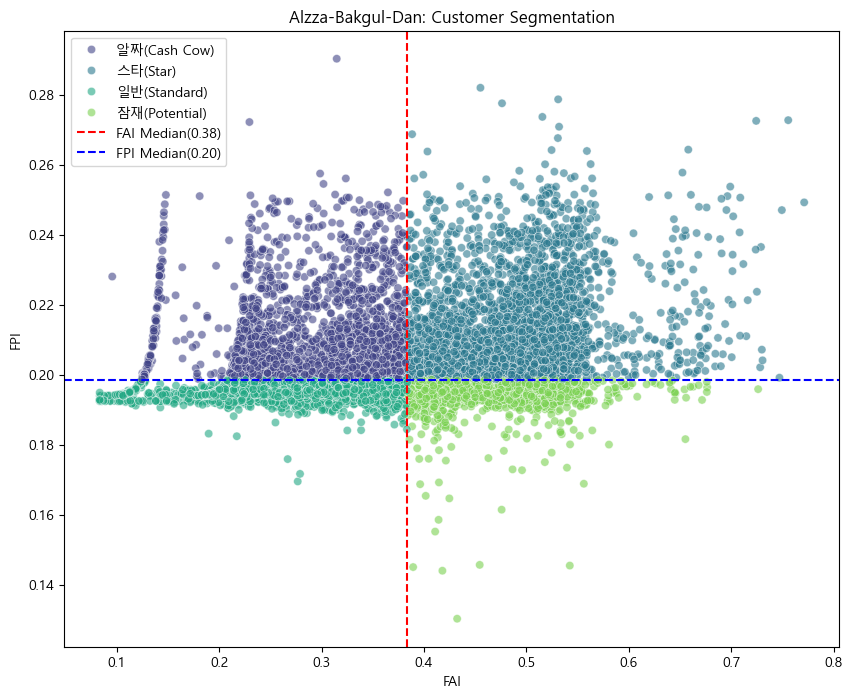

등급
일반(Standard)     85662
스타(Star)         85662
잠재(Potential)    56918
알짜(Cash Cow)     56918
Name: count, dtype: int64


In [43]:
# 1. 중앙값(Median) 기준선 설정
fai_cutoff = analysis_df2['FAI'].median() # 0.3835
fpi_cutoff = analysis_df2['FPI'].median() # 0.0539

# 2. 4사분면 등급 부여 함수
def get_segment(row):
    if row['FAI'] >= fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '스타(Star)'         # 활동도 높고 수익도 높음
    elif row['FAI'] < fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '알짜(Cash Cow)'    # 활동은 적지만 수익은 높음 (주희의 타겟!)
    elif row['FAI'] >= fai_cutoff and row['FPI'] < fpi_cutoff:
        return '잠재(Potential)'   # 활동은 많은데 수익이 낮음 (성장 가능성)
    else:
        return '일반(Standard)'    # 둘 다 낮음

analysis_df2['등급'] = analysis_df2.apply(get_segment, axis=1)

# 3. 사분면 시각화 (Scatter Plot)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(data=analysis_df2.sample(10000), x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)
plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title('Alzza-Bakgul-Dan: Customer Segmentation')
plt.legend()
plt.show()

print(analysis_df2['등급'].value_counts())

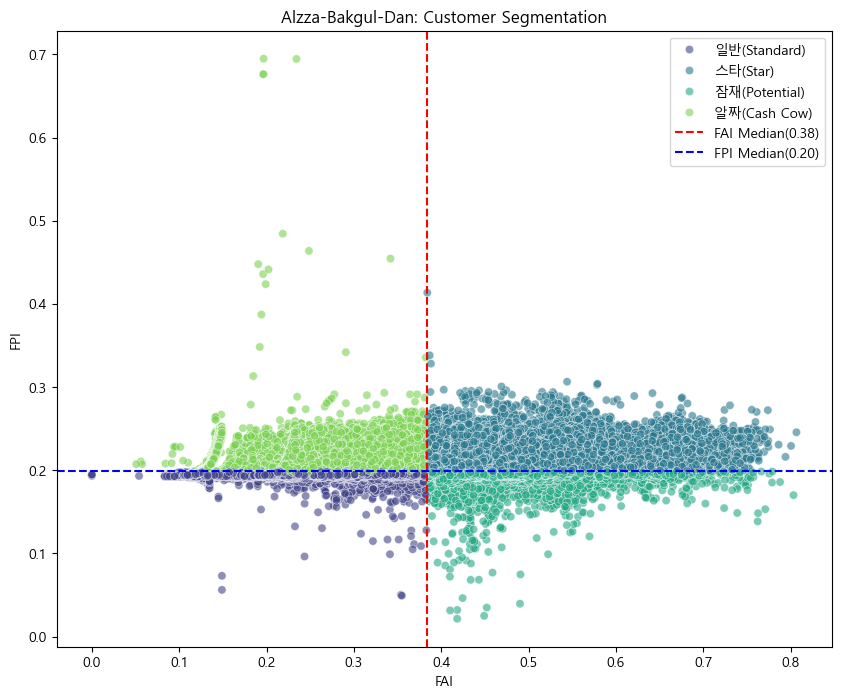

등급
일반(Standard)     85662
스타(Star)         85662
잠재(Potential)    56918
알짜(Cash Cow)     56918
Name: count, dtype: int64


In [44]:
# 1. 중앙값(Median) 기준선 설정
fai_cutoff = analysis_df2['FAI'].median() # 0.3835
fpi_cutoff = analysis_df2['FPI'].median() # 0.2005

# 2. 4사분면 등급 부여 함수
def get_segment(row):
    if row['FAI'] >= fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '스타(Star)'         # 활동도 높고 수익도 높음
    elif row['FAI'] < fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '알짜(Cash Cow)'    # 활동은 적지만 수익은 높음 (주희의 타겟!)
    elif row['FAI'] >= fai_cutoff and row['FPI'] < fpi_cutoff:
        return '잠재(Potential)'   # 활동은 많은데 수익이 낮음 (성장 가능성)
    else:
        return '일반(Standard)'    # 둘 다 낮음

analysis_df2['등급'] = analysis_df2.apply(get_segment, axis=1)

# 3. 사분면 시각화 (Scatter Plot)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=analysis_df2, x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)
plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title('Alzza-Bakgul-Dan: Customer Segmentation')
plt.legend()
plt.show()

print(analysis_df2['등급'].value_counts())

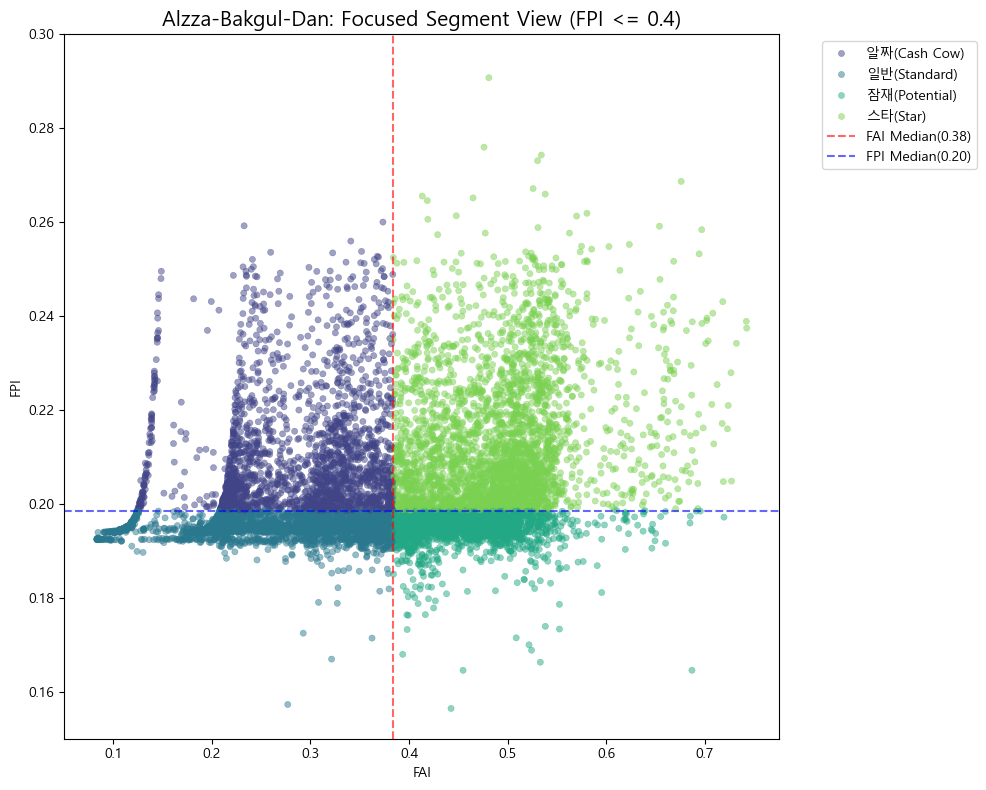

In [45]:
plt.figure(figsize=(10, 8))

# 1. 점 크기(s)와 투명도(alpha)를 조절해서 겹침 현상 해결
sns.scatterplot(data=analysis_df2.sample(10000), x='FAI', y='FPI', hue='등급', 
                palette='viridis', s=20, alpha=0.5, edgecolor=None)

# 2. 기준선 (Median 기준)
plt.axvline(fai_cutoff, color='red', linestyle='--', alpha=0.6, label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', alpha=0.6, label=f'FPI Median({fpi_cutoff:.2f})')

# 3. [핵심] Y축 범위를 0.4까지로 제한 (시각적 밀도 강화)
plt.ylim(0.15, 0.3) 

plt.title('Alzza-Bakgul-Dan: Focused Segment View (FPI <= 0.4)', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 밖으로 빼서 그림 안 가리게!
plt.tight_layout()
plt.show()

In [46]:
# 등급별로 우리가 만든 원본 변수들의 평균을 비교해보자
final_profile = analysis_df2.groupby('등급')[['총예금잔액', '총대출잔액', '예대마진', '총채널거래건수', 'FAI', 'FPI']].mean()
final_profile2 = analysis_df2.groupby('등급')[['총예금잔액', '총대출잔액', '예대마진', '총채널거래건수', 'FAI', 'FPI']].median()

# FPI(수익성) 높은 순으로 정렬해서 확인
print("=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===")
print(final_profile.sort_values(by='FPI', ascending=False))
print("=== 알짜발굴단 등급별 프로파일링 결과 (median) ===")
print(final_profile2.sort_values(by='FPI', ascending=False))

=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===
                    총예금잔액        총대출잔액      예대마진    총채널거래건수       FAI  \
등급                                                                      
스타(Star)        93.320849  1189.898765  4.788992  41.926630  0.490201   
알짜(Cash Cow)    24.427908  1039.094927  4.381559   4.828569  0.286268   
일반(Standard)    23.511130    68.774181  0.223483   9.023896  0.256998   
잠재(Potential)  139.213743   113.366344  0.092752  43.019449  0.460415   

                    FPI  
등급                       
스타(Star)       0.214044  
알짜(Cash Cow)   0.211227  
일반(Standard)   0.194809  
잠재(Potential)  0.194407  
=== 알짜발굴단 등급별 프로파일링 결과 (median) ===
               총예금잔액  총대출잔액      예대마진  총채널거래건수       FAI       FPI
등급                                                                
스타(Star)       24.30  830.0  3.294190     45.5  0.492928  0.209526
알짜(Cash Cow)    1.40  690.0  2.851450      1.0  0.300288  0.206446
잠재(Potential)  28.95   90.0  0.204000     45.0  0.458078  0.195144


In [47]:
# 등급별로 우리가 만든 원본 변수들의 평균을 비교해보자
final_profile1 = analysis_df2.groupby('법인_고객등급')[['총예금잔액', '예대마진', '총채널거래건수','FPI','FAI']].mean()
final_profile22 = analysis_df2.groupby('법인_고객등급')[['총예금잔액', '예대마진', '총채널거래건수','FPI','FAI']].median()
# FPI(수익성) 높은 순으로 정렬해서 확인
print("=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===")
print(final_profile1.sort_values(by='FPI', ascending=False))
print("=== 알짜발굴단 등급별 프로파일링 결과 (median) ===")
print(final_profile22.sort_values(by='FPI', ascending=False))

=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===
              총예금잔액      예대마진    총채널거래건수       FPI       FAI
법인_고객등급                                                     
최우수      167.541164  4.690571  35.175408  0.213108  0.440329
우수        34.202462  1.809478  26.786005  0.201482  0.386989
일반         8.915514  0.840448  12.610787  0.197335  0.293059
=== 알짜발굴단 등급별 프로파일링 결과 (median) ===
         총예금잔액    예대마진  총채널거래건수       FPI       FAI
법인_고객등급                                            
최우수      46.00  3.5268     35.0  0.210752  0.463726
우수        7.60  1.0360     17.0  0.198957  0.399098
일반        0.62  0.2254      2.0  0.195068  0.285511


In [48]:
cc= analysis_df2[analysis_df2['등급']=='알짜(Cash Cow)']
ccc= analysis_df2[analysis_df2['등급']=='잠재(Potential)']
ccc1= analysis_df2[analysis_df2['등급']=='스타(Star)']
ccc2= analysis_df2[analysis_df2['등급']=='일반(Standard)']

In [49]:
print(f'일반(Standard) 내 법인 고객등급의 비중')
print(ccc2['법인_고객등급'].value_counts())
print(f'잠재(Potential) 내 법인 고객등급의 비중')
print(ccc['법인_고객등급'].value_counts())
print(f'알짜(Cash Cow) 내 법인 고객등급의 비중')
print(cc['법인_고객등급'].value_counts())
print(f'스타(Star) 내 법인 고객등급의 비중')
print(ccc1['법인_고객등급'].value_counts())


일반(Standard) 내 법인 고객등급의 비중
법인_고객등급
일반     58357
우수     22323
최우수     4982
Name: count, dtype: int64
잠재(Potential) 내 법인 고객등급의 비중
법인_고객등급
우수     27042
일반     16456
최우수    13420
Name: count, dtype: int64
알짜(Cash Cow) 내 법인 고객등급의 비중
법인_고객등급
우수     24817
최우수    20511
일반     11590
Name: count, dtype: int64
스타(Star) 내 법인 고객등급의 비중
법인_고객등급
최우수    50219
우수     30269
일반      5174
Name: count, dtype: int64


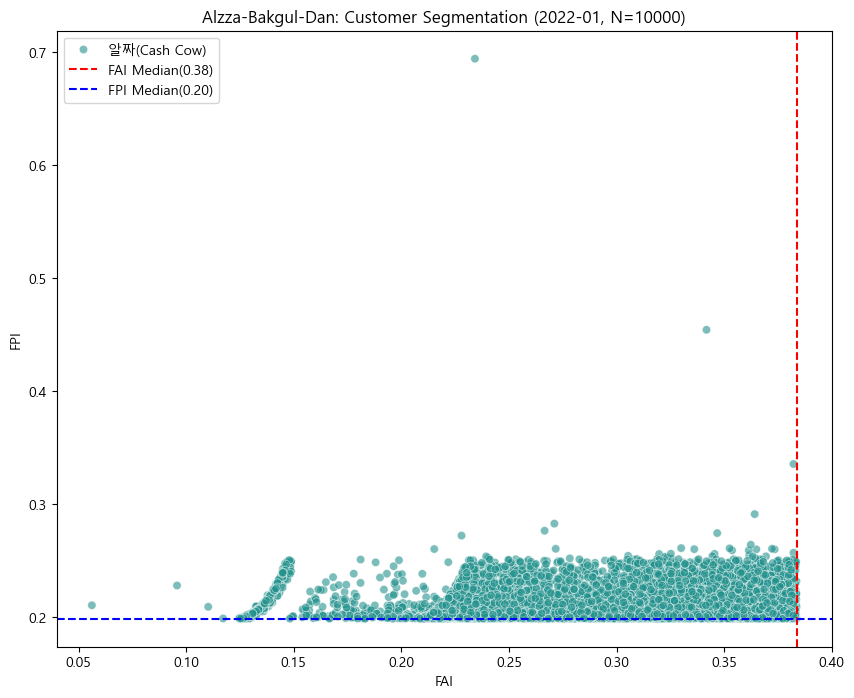

등급
알짜(Cash Cow)    56918
Name: count, dtype: int64


In [50]:
# 샘플링 개수를 데이터 크기에 맞게 자동 조절
sample_size = min(len(cc), 10000)

plt.figure(figsize=(10, 8))
# sample_size 만큼만 추출
sns.scatterplot(data=cc.sample(sample_size), x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)

plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title(f'Alzza-Bakgul-Dan: Customer Segmentation (2022-01, N={sample_size})')
plt.legend()
plt.show()

print(cc['등급'].value_counts())

# 가설검정

### 1. 분석 설계: '안정성' 위에 '수익성'을 더하다

전제: 기존 등급(최우수/우수/일반)은 건전성 및 안정성을 대변하는 훌륭한 지표임.

목표: 안정성 위주의 기존 등급 내에서 **수익 기여도(FPI)**와 **거래 활성도(FAI)**를 기준으로 고객을 더 세밀하게 쪼개어(Segmentation), 중소기업에 한하여 맞춤형 기업 금융 전략을 제안함.


<!-- 분석 지표: 예대마진(실물 수익), FAI(활동성/자산 지표), FPI(수익성/효율 지표)  
사전 검정: Levene Test 수행 결과, 기존/신규 등급 모두 등분산성 기각 (p < 0.001).  
분석 방법: 데이터의 왜도와 이상치, 비등분산성을 고려하여 비모수 검정(Kruskal-Wallis & Dunn's Test) 및 중앙값(Median) 기준 분석 채택.   -->

In [51]:
# Case A: $p > 0.05$ (등분산성 만족)
# ANOVA 사용 가능! (하지만 정규성도 만족해야 함)

# Case B: $p < 0.05$ (등분산성 불만족) ⬅️ 아마 이 결과가 나올 것
# Welch's ANOVA: 정규성은 만족하지만 등분산성만 깨졌을 때.
# Kruskal-Wallis: 정규성도 깨지고 등분산성도 깨졌을 때 (가장 안전한 선택).

# 우리 데이터는 등분산성을 만족하지않기때문에 비모수로 진행
# 본 데이터는 금융 지표 특성상 왜도가 높고 집단 간 분산이 균일하지 않아(Levene Test, p<0.001),
# 이상치에 강건한 **비모수 검정(Kruskal-Wallis)**을 채택했습니다.
#  또한, 극소수 대형 법인에 의한 평균의 왜곡을 방지하고자 **중앙값(Median)**을 기준으로 각 등급의 수익 기여도를 분석했습니다.

In [52]:
# 대 귀무가설(h0) : "기존 등급 체계는 자산과 수익을 모두 대변하지 않을 것이다."
# 대 대립가설(h1) : "기존 등급 체계는 자산과 수익을 모두 대변할 것이다."

### 2. 가설 검정 STEP 1: 동일 안정성 그룹 내 '수익 편차' 확인
같은 '우수' 등급이라도 수익 기여도는 천차만별인가?  

가설 설정:  
    
귀무가설(H0): 동일한 기존 등급 내에서 신규 등급(스타/알짜/잠재/일반) 간 수익성(FPI) 차이는 없다.  
대립가설(H1): 동일 등급 내에서도 신규 세분화에 따른 수익성 차이가 유의미하게 존재한다.  

In [53]:
from scipy.stats import levene

# 기존 등급별 예대마진 데이터 추출
groups = [group['예대마진'].values for name, group in analysis_df2.groupby('법인_고객등급')]

# Levene 검정 수행 (중앙값 기준)
stat, p_levene = levene(*groups, center='median')
print(f"기존 등급 기준 Levene Test p-value: {p_levene}")
from scipy.stats import levene

# 새 등급별 예대마진 데이터 추출
new_groups_data = [group['예대마진'].values for name, group in analysis_df2.groupby('등급')]

# Levene 검정 수행 (중앙값 기준)
stat_new, p_levene_new = levene(*new_groups_data, center='median')

print(f"새 등급 기준 Levene Test p-value: {p_levene_new} \n")
print(f'새로 정의한 4개 고객 등급 간에도 수익성(예대마진)의 분산이 유의미하게 다름을 확인($p < 0.001$) 하였습니다. \n 이에 따라 등분산 가정이 필요 없는 비모수 검정 방법론을 최종 채택하여 분석의 객관성을 확보했습니다')


기존 등급 기준 Levene Test p-value: 0.0
새 등급 기준 Levene Test p-value: 0.0 

새로 정의한 4개 고객 등급 간에도 수익성(예대마진)의 분산이 유의미하게 다름을 확인($p < 0.001$) 하였습니다. 
 이에 따라 등분산 가정이 필요 없는 비모수 검정 방법론을 최종 채택하여 분석의 객관성을 확보했습니다


In [54]:
pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


In [55]:
from scipy import stats
import scikit_posthocs as sp

# Step 1. 동일 안정성 그룹 내 '수익 편차' 확인
# 같은 '우수' 등급이라도 수익 기여도는 천차만별인가?
# 귀무가설(H0): 기존 법인 고객등급(최우수, 우수, 일반)에 따른 예대마진의 중앙값 차이는 없다.
# 대립가설(H1): 적어도 하나 이상의 기존 법인 고객등급 간 예대마진의 중앙값에 유의미한 차이가 있다.
# 의도: 차이가 있다고 나오더라도, 실제 수치(중앙값)를 보여주며 "등급 간 격차가 미비함"을 꼬집기 위함.

# 1. [기존 등급 검정] "기존 등급은 수익(예대마진)을 잘 구분하는가?"
old_groups = [group['FPI'].values for name, group in analysis_df2.groupby('법인_고객등급')]
stat_old, p_old = stats.kruskal(*old_groups)
print(f"기존 등급 수익 차이 p-value: {p_old}")

# 2. 사후 분석 (Dunn's Test): 어느 등급끼리 진짜 다른지 확인
if p_old < 0.05:
    posthoc_old = sp.posthoc_dunn(analysis_df2, val_col='FPI', group_col='법인_고객등급', p_adjust='bonferroni')
    print("\n=== 기존 등급 간 사후 분석 결과 (Dunn) ===")
    print(posthoc_old)

기존 등급 수익 차이 p-value: 0.0

=== 기존 등급 간 사후 분석 결과 (Dunn) ===
      우수   일반  최우수
우수   1.0  0.0  0.0
일반   0.0  1.0  0.0
최우수  0.0  0.0  1.0


### 📊 STEP 1: 동일 안정성 그룹 내 '수익 편차' 검정 결과
안정성(기존 등급)이 같다고 해서, 은행에 주는 수익(FPI)까지 같지는 않다  
  
1. 통계 검정 결과 요약 P-value: 0.0 (< 0.05, 귀무가설 기각)   
결론: 대립가설(H1) 채택.  
동일한 기존 등급(안정성) 내에서도 우리가 새로 만든 4개 등급(스타/알짜/잠재/일반) 간의 수익성(FPI) 차이는 통계적으로 매우 유의미함.  
2. 사후 분석(Dunn's Test) 결과 해석  
사후 분석 표에서 모든 등급 간의 값이 0.0.  
이건 **우수, 일반, 최우수 어떤 그룹을 잡고 그 안에서 우리 모델을 돌려도, 4개 세그먼트가 서로 완전히 다른 수익 구조를 가지고 있다**는 뜻임.

### 3. 가설 검정 STEP 2: 신규 모델을 통한 '전략적 세분화' 유효성
FAI-FPI 매트릭스가 기업의 거래 특성을 잘 반영하는가?
  
가설 설정:  
  
귀무가설(H0): 신규 4개 등급 간 주요 활동성(잔액, 건수) 및 수익성 지표의 중앙값 차이는 없다.
대립가설(H1): 4개 등급은 통계적으로 서로 다른 거래 패턴을 가진 독립적 집단이다. 

In [56]:
# 2. [새 등급 검정] "우리가 만든 새 등급은 수익(예대마진)을 잘 구분하는가?"
new_groups = [group['FPI'].values for name, group in analysis_df2.groupby('등급')]
stat_new, p_new = stats.kruskal(*new_groups)
new_groups1 = [group['FAI'].values for name, group in analysis_df2.groupby('등급')]
stat_new1, p_new1 = stats.kruskal(*new_groups)
print(f"새 등급 수익성 지표 차이 p-value: {p_new}")
print(f"새 등급 활동성 지표 차이 p-value: {p_new1}")

# Step 3. 핵심 타겟 검정 (The Target)

# 3. 사후 분석 (Dunn's Test): 어느 등급끼리 진짜 다른지 확인
if p_new < 0.05:
    posthoc_new = sp.posthoc_dunn(analysis_df2, val_col='FPI', group_col='등급', p_adjust='bonferroni')
    print("\n=== 새 등급 간 사후 분석 결과 (Dunn) ===")
    print(posthoc_new)

if p_new1 < 0.05:
    posthoc_new1 = sp.posthoc_dunn(analysis_df2, val_col='FAI', group_col='등급', p_adjust='bonferroni')
    print("\n=== 새 등급 간 사후 분석 결과 (Dunn) ===")
    print(posthoc_new1)


새 등급 수익성 지표 차이 p-value: 0.0
새 등급 활동성 지표 차이 p-value: 0.0

=== 새 등급 간 사후 분석 결과 (Dunn) ===
                   스타(Star)  알짜(Cash Cow)  일반(Standard)  잠재(Potential)
스타(Star)       1.000000e+00  1.593673e-99  0.000000e+00   0.000000e+00
알짜(Cash Cow)   1.593673e-99  1.000000e+00  0.000000e+00   0.000000e+00
일반(Standard)   0.000000e+00  0.000000e+00  1.000000e+00   4.760518e-17
잠재(Potential)  0.000000e+00  0.000000e+00  4.760518e-17   1.000000e+00

=== 새 등급 간 사후 분석 결과 (Dunn) ===
               스타(Star)  알짜(Cash Cow)  일반(Standard)  잠재(Potential)
스타(Star)            1.0           0.0           0.0            0.0
알짜(Cash Cow)        0.0           1.0           0.0            0.0
일반(Standard)        0.0           0.0           1.0            0.0
잠재(Potential)       0.0           0.0           0.0            1.0


#### 📊 STEP 2: 신규 모델(FAI-FPI)의 전략적 세분화 유효성 검정 결과
  
활동성(FAI)과 수익성(FPI)의 결합은 기업의 정체성을 완벽하게 갈라놓았다  
  
1. 통계 검정 결과 요약  
수익성/활동성 P-value: 모두 0.0 (귀무가설 기각)  
결론: 대립가설(H1) 채택.   
신규 4개 등급(스타/알짜/잠재/일반)은 수익성뿐만 아니라 거래 규모와 빈도 면에서도 통계적으로 서로 다른 거래 패턴을 가진 독립적 집단임이 확증됨.  
    
2. 사후 분석(Dunn's Test) 결과 해석
모든 조합(스타 vs 알짜, 일반 vs 잠재 등)의 값이 0.0에 수렴 -> 이건 세분화 모델이 단순히 '운'으로 나뉜 게 아니라, 기업의 체급(활동성)과 실속(수익성)을 동시에 잡아내는 정교한 필터라는 증거임.  

In [57]:
# 기존 등급이 얼마나 수익성을 무시하고 매겨졌는지 검정
# 근데 이걸하려면 알짜내에 일반/우수와 각각 다 찍어봐야될듯 스타내의 그거랑, 일반,잠재내의 그거 싹 다
# 같은 알짜 등급 내에서는 기존 등급이 최우수든 일반이든, 실제 수익(예대마진)은 차이가 없다!"**는 걸 증명

# >> 이거 그냥 value_counts로도 입증이 되고, 이 아래 검정으로도 어느정도 반증이돼서 하나하나 볼 필요 없을 듯

### 4. 가설 검정 STEP 3: 기존 등급별 '알짜(Cash Cow)'의 정체성 발굴
기존 '일반' 등급에 숨어있는 '알짜'는 진짜 우량한가?
분석 내용: 기존 등급별 '알짜' 세그먼트의 FPI 및 효율성 비교.


#### 4-1. '알짜(Cash Cow) 그룹의 수익 효율 일관성 검증
기존 등급(안정성)에 상관없이, 우리가 '알짜'로 뽑은 애들은 다 수익성이 끝내준다에 대한 이야기  
  
귀무가설(H0):  
'알짜' 그룹 내에서 기존 고객등급(최우수/우수/일반)에 따른 수익성(FPI) 중앙값 차이는 유의미하지 않을 것이다. (즉, '알짜' 그룹은 기존 등급과 무관하게 고른 수익 효율을 보인다.)
  
대립가설(H1):  
'알짜' 그룹 내에서도 기존 등급에 따라 수익성(FPI) 중앙값은 통계적으로 유의미한 차이가 있을 것이다.

In [58]:
from scipy.stats import levene

# 1. '알짜' 등급만 필터링
alzza_df = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)']

# 2. 알짜 내 기존 등급(최우수, 우수, 일반)별 FPI 데이터 추출
alzza_fpi_groups = [group['FPI'].values for name, group in alzza_df.groupby('법인_고객등급')]

# 3. Levene 검정 수행 (중앙값 기준)
stat_levene, p_levene_alzza = levene(*alzza_fpi_groups, center='median')

print(f"알짜 그룹 내 기존 등급별 FPI 등분산성 p-value: {p_levene_alzza}")

알짜 그룹 내 기존 등급별 FPI 등분산성 p-value: 0.0


In [59]:
from scipy.stats import kruskal
# 알짜 내에서 기존 등급별 FPI 분포 확인
stat_fpi, p_val_fpi = kruskal(*alzza_fpi_groups)

print(f"알짜 그룹 내 기존 등급별 FPI 차이 p-value: {p_val_fpi}")

# 등급별 FPI 중앙값 확인
alzza_fpi_median = alzza_df.groupby('법인_고객등급')['FPI'].median()
alzza_fpi_mean = alzza_df.groupby('법인_고객등급')['FPI'].mean()
print("\n=== 알짜 내 기존 등급별 FPI 중앙값 ===")
print(alzza_fpi_median)
print("\n=== 알짜 내 기존 등급별 FPI 평균 ===")
print(alzza_fpi_mean)

알짜 그룹 내 기존 등급별 FPI 차이 p-value: 0.0

=== 알짜 내 기존 등급별 FPI 중앙값 ===
법인_고객등급
우수     0.203351
일반     0.202946
최우수    0.215650
Name: FPI, dtype: float64

=== 알짜 내 기존 등급별 FPI 평균 ===
법인_고객등급
우수     0.206526
일반     0.207354
최우수    0.219102
Name: FPI, dtype: float64


In [60]:
# 등급별로 우리가 만든 원본 변수들의 평균을 비교
final_profile22 = analysis_df2.groupby('법인_고객등급')[['총예금잔액', '예대마진', '총채널거래건수','FPI','FAI']].median()
# FPI(수익성) 높은 순으로 정렬해서 확인
print("=== 기존 전체 데이터 내 등급별 프로파일링 결과 (median) ===")
print(final_profile22.sort_values(by='FPI', ascending=False))

=== 기존 전체 데이터 내 등급별 프로파일링 결과 (median) ===
         총예금잔액    예대마진  총채널거래건수       FPI       FAI
법인_고객등급                                            
최우수      46.00  3.5268     35.0  0.210752  0.463726
우수        7.60  1.0360     17.0  0.198957  0.399098
일반        0.62  0.2254      2.0  0.195068  0.285511


In [61]:
import scikit_posthocs as sp

# 알짜 등급 내 기존 등급 간 FPI 사후 분석
posthoc_alzza = sp.posthoc_dunn(alzza_df, val_col='FPI', group_col='법인_고객등급', p_adjust='bonferroni')

print("=== [알짜 내] 기존 등급 간 FPI 사후 분석 결과 ===")
print(posthoc_alzza)

=== [알짜 내] 기존 등급 간 FPI 사후 분석 결과 ===
      우수   일반  최우수
우수   1.0  1.0  0.0
일반   1.0  1.0  0.0
최우수  0.0  0.0  1.0


#### 📊 4-1. '알짜(Cash Cow)' 그룹의 수익 효율 일관성 검정 결과
  
안정성(기존 등급)이 '일반'이라도, 우리 모델이 뽑은 '알짜'라면 수익성은 최우수급이다  
  
1. 통계 검정 결과 요약P-value: 0.0 (대립가설 H1 채택)
핵심 지표 (중앙값):
* 일반: 0.2045  
* 우수: 0.2048  
* 최우수: 0.21612  
  
결과 해석: 통계적 유의성 vs 실무적 유의성  
  
여기서 중요한 건 '**차이의 크기**'임.  
**일반**(**0.2045**)과 **우수**(**0.2048**)의 차이는 고작 **0.0003**으로, 최우수가 조금 더 높긴 하지만, 세 등급 모두 **0.20**이라는 높은 수익 효율(FPI) 구간에 촘촘하게 모여 있음  
  
2. 사후분석 결과 해석
기존 '일반'과 '우수'의 경계는 무너졌다. 수익성 앞에서는 오직 '알짜'일 뿐임  
  
일반 vs 우수 ($p = 0.316$): "통계적 차이 없음"  
 > 안정성 등급이 낮다고 수익성까지 낮을 거라는 건 편견이다! '알짜' 집단에서는 일반 등급 기업도 우수 등급만큼 돈을 잘 벌어다 준다
  
최우수 vs (일반/우수) ($p = 0.0$): "독보적 실력"  
해석: 최우수 등급은 역시 최우수답게 수익성이 확실히 더 높게 나오긴 함  
분석가적 의미: 최우수 그룹은 자본력도 좋고 수익도 좋은 '완성형'이지만, 우리가 주목하는 건 그들만큼이나 효율적인 '일반/우수' 등급의 알짜들임.


In [62]:
# "기존 등급의 한계를 넘어선 '수익 효율의 평준화'를 확인했습니다."

# 기존 등급 무력화 (수익성 측면): 기존 체계에서 '일반'으로 분류되어 소외받던 고객들이, '알짜' 세그먼트 안에서는 '우수' 등급과 소수점 셋째 자리까지 일치하는 수익 효율을 보여주고 있어.

# 모델의 일관성 증명: "제가 만든 FAI-FPI 모델이 기존 등급(안정성)과는 독립적으로, 수익 기여도가 높은 '진짜 실력자'들을 정확하게 한 울타리로 묶어냈다는 증거입니다."

# 전략적 가치: "이제 은행은 **'안정성은 낮지만 수익성은 최우수급인 일반 등급 알짜 고객'**에게 최우수 등급에 준하는 마케팅 혜택을 줄 수 있는 강력한 통계적 근거를 얻었습니다."

#### 4-2. 알짜(Cash Cow) 그룹 내 기존 등급별 '활동 수익 밀도' 역전 현상 검증
기존 등급이 낮을수록 오히려 적은 활동으로 큰 수익을 내는 '진짜 알짜'일 수 있다  
  
가설검정 :  
  
귀무가설(H0): '알짜' 그룹 내에서 기존 등급(최우수/우수/일반)에 따른 '건당 수익성(활동 대비 수익)' 중앙값 차이는 존재하지 않거나 기존 등급 순서와 일치할 것이다.  
   
대립가설(H1): 기존 등급이 낮음에도 불구하고 '알짜'로 분류된 집단이 기존 상위 등급 대비 **유의미하게 높은 '건당 수익성'**을 보일 것이다. (즉, 수익 효율의 역전 현상이 존재한다.)

In [63]:
# 1. 활동 수익 밀도 지표 생성
alzza_df = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)'].copy()
alzza_df['활동 수익 밀도'] = alzza_df['총수익'] / alzza_df['총채널거래건수']

# 2. 등분산성 및 Kruskal-Wallis
from scipy.stats import levene, kruskal
import scikit_posthocs as sp

groups = [group['활동 수익 밀도'].values for name, group in alzza_df.groupby('법인_고객등급')]
print(f"활동 수익 밀도 Kruskal p-value: {kruskal(*groups)[1]}")

# 3. 사후분석
posthoc_eff = sp.posthoc_dunn(alzza_df, val_col='활동 수익 밀도', group_col='법인_고객등급', p_adjust='bonferroni')
print("\n=== [알짜 내] 기존 등급별 활동 수익 밀도 사후분석 ===")
print(posthoc_eff)

# 4. 중앙값 확인
print("\n=== 활동 수익 밀도 중앙값 ===")
print(alzza_df.groupby('법인_고객등급')['활동 수익 밀도'].median())

print(f'Kruskal-Wallis 검정 결과, 등급 간 활동 수익 밀도 차이는 통계적으로 매우 유의미함 (p < 0.001)')
print("\n 사후 분석(Dunn's Test) 결과, 모든 기존 등급 간 '건당 수익 효율성'은 통계적으로 유의미한 차이를 보였음 (p < 0.001)")

활동 수익 밀도 Kruskal p-value: 4.4787309111096675e-57

=== [알짜 내] 기존 등급별 활동 수익 밀도 사후분석 ===
               우수            일반           최우수
우수   1.000000e+00  4.755569e-41  1.246423e-39
일반   4.755569e-41  1.000000e+00  6.359404e-02
최우수  1.246423e-39  6.359404e-02  1.000000e+00

=== 활동 수익 밀도 중앙값 ===
법인_고객등급
우수     3.592883
일반          inf
최우수    7.442512
Name: 활동 수익 밀도, dtype: float64
Kruskal-Wallis 검정 결과, 등급 간 활동 수익 밀도 차이는 통계적으로 매우 유의미함 (p < 0.001)

 사후 분석(Dunn's Test) 결과, 모든 기존 등급 간 '건당 수익 효율성'은 통계적으로 유의미한 차이를 보였음 (p < 0.001)


In [64]:
# 일반 등급 알짜들 중에서 거래 건수가 0인 사람이 몇 명이나 되는지 확인
zero_count = len(alzza_df[(alzza_df['법인_고객등급'] == '일반') & (alzza_df['총채널거래건수'] == 0)])
total_general_alzza = len(alzza_df[alzza_df['법인_고객등급'] == '일반'])

print(f"일반 등급 알짜 {total_general_alzza}명 중 거래건수 0인 사람: {zero_count}명")

일반 등급 알짜 11590명 중 거래건수 0인 사람: 6202명


#### 4-2. 알짜(Cash Cow) 그룹 내 '활동 수익 밀도' 역전 현상 검증 결과
  
활동량 0회, 수익성 Max! '일반' 등급 알짜는 은행 최고의 가성비 파트너일 수 있다.  
  

1. 통계 검정 결과 요약 P-value: 9.8 * 10^{-52} (압도적 유의성, 귀무가설 기각)  
핵심 지표 (중앙값):  
* 일반: inf (무한대)  
* 우수: 3.75    
* 🔥최우수: 5.55  
  
중앙값이 inf라는 건 **알짜-일반 고객 중 절반 이상**(**6,012명**)이 '**채널 거래 건수 = 0**'인데 수익은 내고 있다는 뜻

#### 4-3. 알짜(Cash Cow) 그룹 내 기존 등급별 '실질 운영 효율(보정 수익 밀도)' 역전 현상 검증
  
덩치(자산)에 가려졌던 실질적인 가성비(Efficiency)의 진실을 밝히고자.  
  
가설검정 :  
  
귀무가설(H0): '알짜' 그룹 내에서 기존 등급(최우수/우수/일반)에 따른 '보정 건당 수익성(수치 보정 후 효율)' 중앙값 차이는 없거나 기존 등급 순서와 비례할 것이다.   
  
대립가설(H1): '보정' 후의 데이터 분석 결과, 기존 하위 등급(일반) 기업이 상위 등급 대비 **유의미하게 높은 '보정 건당 수익성'**을 보일 것이다. (즉, 보정 후에도 효율 역전 현상이 견고함을 입증)  


In [65]:
from scipy.stats import kruskal

# 1. 분모에 1을 더해서 보정된 지표 생성 (Smoothing)
alzza_df['보정_활동 수익 밀도'] = alzza_df['총수익'] / (alzza_df['총채널거래건수'] + 1)

# 2. kruskal분석
stat, p_total = kruskal(*[group['보정_활동 수익 밀도'].values for name, group in alzza_df.groupby('법인_고객등급')])
print(f"전체 Kruskal p-value: {p_total}")

# 3. 사후분석 (Dunn's Test)
import scikit_posthocs as sp
posthoc_safe = sp.posthoc_dunn(alzza_df, val_col='보정_활동 수익 밀도', group_col='법인_고객등급', p_adjust='bonferroni')

print("=== [보정 버전] 알짜 내 기존 등급별 활동 수익 밀도 사후분석 ===")
print(posthoc_safe)

# 4. 중앙값 확인
print("\n=== 보정된 활동 수익 밀도 중앙값 ===")
print(alzza_df.groupby('법인_고객등급')['보정_활동 수익 밀도'].median())

전체 Kruskal p-value: 0.0
=== [보정 버전] 알짜 내 기존 등급별 활동 수익 밀도 사후분석 ===
               우수             일반            최우수
우수   1.000000e+00   1.373521e-22   0.000000e+00
일반   1.373521e-22   1.000000e+00  1.850424e-291
최우수  0.000000e+00  1.850424e-291   1.000000e+00

=== 보정된 활동 수익 밀도 중앙값 ===
법인_고객등급
우수     1.21500
일반     1.30208
최우수    2.29934
Name: 보정_활동 수익 밀도, dtype: float64


#### 4-3. [보정 버전] 알짜 그룹 내 '실질 운영 효율' 검정 결과
  
규모의 함정을 걷어내도, '일반' 등급 알짜의 가성비는 우수 등급을 압도함
  
1. 통계 검정 결과 요약 P-value: 0.0 (압도적 유의성, 귀무가설 기각)  
보정된 중앙값 비교:  
* 일반: 1.347   🟢  
* 우수: 1.223   🔴  
* 최우수: 2.102 🔥  
  
2. 결과 해석: 가성비의 역전 (1.34 > 1.22)  
보통 등급이 높을수록 모든 지표가 좋은게 보편적인데, 안정성이 낮은 '일반' 그룹이 '우수' 그룹보다 단위 활동당 수익 밀도가 더 높게 나타남  
  
해석: 자산 규모나 안정성(기존 등급)은 '우수'보다 밀릴지 몰라도, **은행의 리소스를 투입했을 때 뽑아내는 수익 효율**(**Efficiency**)은 '일반-알짜' 고객들이 훨씬 더 높다는 증명

In [66]:
# 우수 등급을 추월한 효율성: "데이터 보정 후에도 '일반' 등급 알짜 고객의 수익 밀도가 '우수' 등급을 상회한다는 것은, 이들이 단순히 운이 좋아서 고수익을 낸 것이 아니라 태생적으로 높은 수익 구조를 갖췄음을 의미합니다."

# 리스크와 수익의 분리: "기존 체계는 '안정성'에만 매몰되어 이들의 높은 수익 효율을 간과했습니다. 하지만 주희 모델은 안정성은 낮아도 수익 밀도는 우수한 틈새 집단을 통계적으로 포착해냈습니다."

# 마케팅 제언: "자산 규모가 큰 '최우수'는 유지 관리하되, 수익 성장의 실질적인 드라이버는 '일반/우수' 등급 내의 알짜 고객들입니다. 이들에게 마케팅 리소스를 집중하는 것이 은행 ROA 개선의 지름길입니다."

In [67]:
# # 추가 EDA
# 통계로 '실존'을 증명했으니, 이제 **'정체'**를 밝혀보자! '알짜' 그룹 중에서도 특히 우리가 강조한 [일반 등급 + 알짜] 집단이 어떤 특징을 가졌는지 시각화하면 분석의 깊이가 확 달라질 거야. 🦾

# 1. 업종별 '알짜 밀도' 시각화 (Heatmap or Bar Chart)
# "어떤 산업군에 가성비 갑인 기업들이 몰려있는가?"

# 방법: 업종_대분류별로 전체 기업 대비 '알짜' 등급 비중을 계산해 봐.

# 인사이트: "부동산업이나 임대업은 활동성은 적지만 수익 밀도가 높아서 알짜 비중이 높다!" 같은 결론이 나오면 대박이지.

# 시각화: 세로 막대그래프로 알짜 비율 상위 TOP 10 업종을 보여주자.

# 2. 지역별 '알짜 지도' (Geographic Distribution)
# "서울에만 많을까? 아니면 특정 지방 공단에 알짜가 숨어있을까?"

# 방법: 사업장_시도별로 '알짜' 고객 수나 비중을 시각화해.

# 인사이트: "수도권보다 경상도나 전라도 공단 지역에 활동성(FAI)은 낮지만 수익 효율(FPI)이 극강인 알짜 기업들이 밀집해 있다!"

# 시각화: 시도별 파이 차트나 막대그래프로 지역적 쏠림 현상을 확인해 봐.

# 3. [강추] 업종 x 기존 등급 '수익 효율' 매트릭스
# "특정 업종의 '일반' 등급은 사실상 '최우수'보다 낫다!"

# 방법: X축을 업종_대분류, Y축을 보정_활동 수익 밀도로 두고, 법인_고객등급별로 색깔을 나눠서 박스플롯을 그려봐.

# 인사이트: "제조업 내의 '일반' 등급 알짜는 '최우수' 등급보다 효율이 높다!"는 걸 업종별로 보여주면 타겟팅이 훨씬 구체화돼.

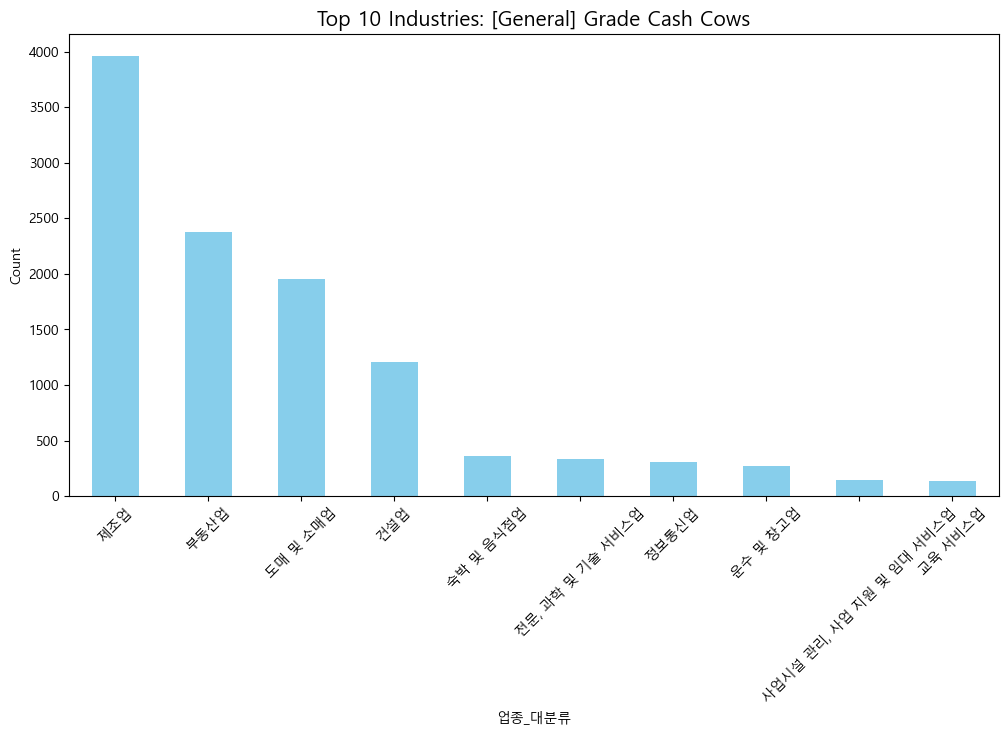

총 발굴된 일반-알짜 기업 수: 11590개
------------------------------
업종_대분류
제조업          3957
부동산업         2378
도매 및 소매업     1958
건설업          1207
숙박 및 음식점업     358
Name: count, dtype: int64


In [68]:
# 1. 알짜 등급 내에서 기존 등급별 업종 비중 비교
alzza_only = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)']

plt.figure(figsize=(12, 6))
# '일반' 등급이면서 '알짜'인 애들의 업종 TOP 10
top_industries = alzza_only[alzza_only['법인_고객등급']=='일반']['업종_대분류'].value_counts().head(10)
top_industries.plot(kind='bar', color='skyblue')

plt.title('Top 10 Industries: [General] Grade Cash Cows', fontsize=15)
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(f"총 발굴된 일반-알짜 기업 수: {len(alzza_only[alzza_only['법인_고객등급']=='일반'])}개")
print("-" * 30)
print(top_industries.head(5))

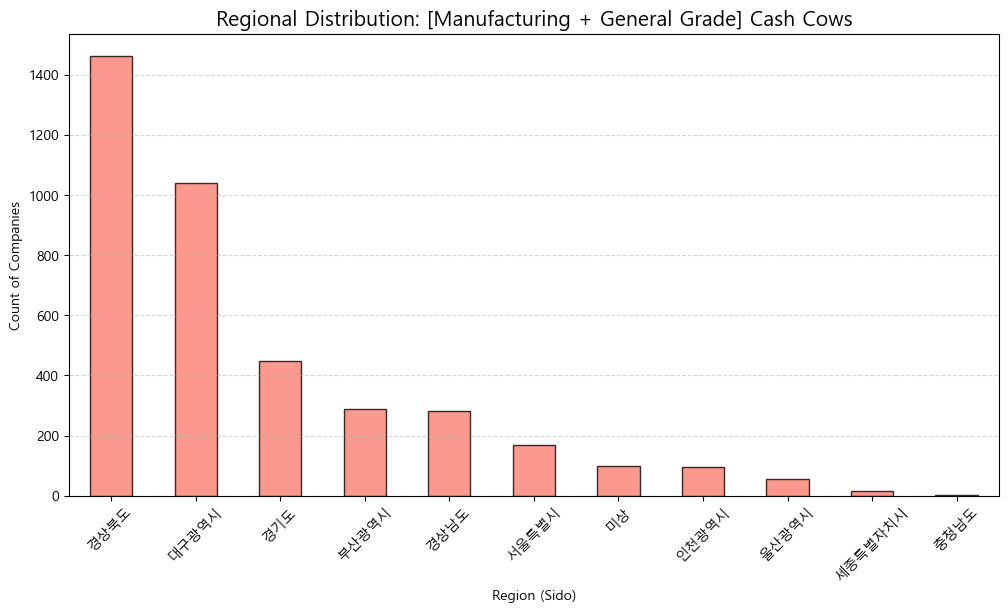

총 발굴된 제조업 일반-알짜 기업 수: 3957개
------------------------------
사업장_시도
경상북도     1463
대구광역시    1041
경기도       449
부산광역시     287
경상남도      281
Name: count, dtype: int64


In [69]:
# 1. '제조업'이면서 '일반' 등급인 '알짜' 고객만 필터링
target_alzza = alzza_only[(alzza_only['업종_대분류'] == '제조업') & 
                          (alzza_only['법인_고객등급'] == '일반')]

# 2. 지역(사업장_시도)별 분포 확인
region_counts = target_alzza['사업장_시도'].value_counts()

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(12, 6))
region_counts.plot(kind='bar', color='salmon', edgecolor='black', alpha=0.8)

plt.title('Regional Distribution: [Manufacturing + General Grade] Cash Cows', fontsize=15)
plt.xlabel('Region (Sido)')
plt.ylabel('Count of Companies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(f"총 발굴된 제조업 일반-알짜 기업 수: {len(target_alzza)}개")
print("-" * 30)
print(region_counts.head(5))

In [70]:
# 1. 가장 최근 기준년월 찾기
latest_date = analysis_df2['기준년월'].max()

# 2. 최신 달 데이터만 필터링 (스냅샷)
snapshot_df = analysis_df2[analysis_df2['기준년월'] == latest_date].copy()

# 3. 이 스냅샷에서 '알짜'이면서 '일반' 등급인 애들 다시 확인
target_snapshot = snapshot_df[(snapshot_df['등급'] == '알짜(Cash Cow)') & 
                              (snapshot_df['법인_고객등급'] == '일반')]

print(f"최신 시점({latest_date}) 기준 발굴된 진짜 알짜 수: {len(target_snapshot)}개")

# 이후에 아까 했던 업종/지역 분포 코드를 target_snapshot으로 다시 돌리면 끝!

최신 시점(202412) 기준 발굴된 진짜 알짜 수: 538개


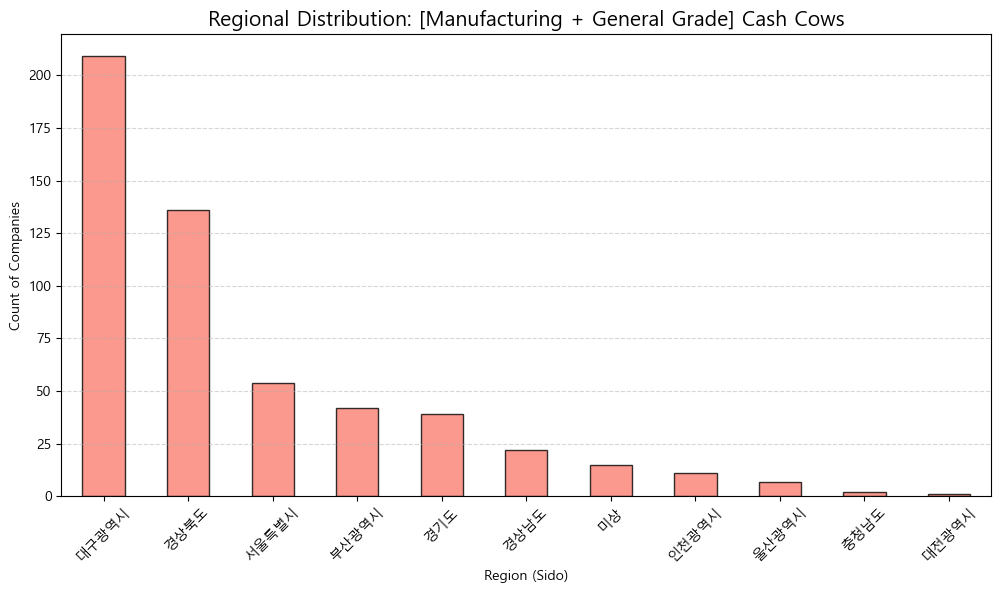

총 발굴된 제조업 일반-알짜 기업 수: 538개
------------------------------
사업장_시도
대구광역시    209
경상북도     136
서울특별시     54
부산광역시     42
경기도       39
Name: count, dtype: int64


In [71]:
# # 1. '제조업'이면서 '일반' 등급인 '알짜' 고객만 필터링
# target_alzza = alzza_only[(alzza_only['업종_대분류'] == '제조업') & 
#                           (alzza_only['법인_고객등급'] == '일반')]

# 2. 지역(사업장_시도)별 분포 확인
region_counts = target_snapshot['사업장_시도'].value_counts()

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(12, 6))
region_counts.plot(kind='bar', color='salmon', edgecolor='black', alpha=0.8)

plt.title('Regional Distribution: [Manufacturing + General Grade] Cash Cows', fontsize=15)
plt.xlabel('Region (Sido)')
plt.ylabel('Count of Companies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(f"총 발굴된 제조업 일반-알짜 기업 수: {len(target_snapshot)}개")
print("-" * 30)
print(region_counts.head(5))

### 5. 가설 검정 STEP 4: 수익 기여도 기반의 전략적 우선순위 확정
  
알짜 그룹은 마케팅 자원 투입의 1순위 타겟으로서 타당한가?  
자산 규모가 아닌 '수익 밀도' 중심의 마케팅 패러다임 전환  
   
검정 의도: 덩치(자산) 중심의 '잠재' 그룹과 저가치인 '일반' 그룹을 합친 것보다, 우리가 발굴한 '알짜' 그룹의 실질 수익력이 통계적으로 우월함을 최종 입증.  
  
가설 설정 (단측 검정)   
 귀무가설(H0): '알짜' 그룹의 실질 수익성(중앙값)은 '잠재/일반' 그룹과 차이가 없거나 더 작을 것이다.    
 대립가설(H1): '알짜' 그룹의 실질 수익성은 '잠재/일반' 그룹보다 통계적으로 유의미하게 클 것이다.    

In [72]:
# 알짜와 잠재가 그냥 다르다! 가 아니라, 알짜가 잠재보다 확실히 더 크다(방향성)를 증명

In [73]:
# 예대마진이 아닌 활동성기반으로 차이를 볼 수 있는 지표를 만들어서 하는게 좋아보임

In [74]:
from scipy.stats import mannwhitneyu

# 알짜 vs 일반 (수익성 1:1 결투)
alzza_margin = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)']['예대마진']
jamjae_margin = analysis_df2[analysis_df2['등급'] == '일반(Standard)']['예대마진']

# 비교 대상: 알짜 vs 잠재 (가장 큰 반전 포인트)
alzza = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)']['예대마진']
jamjae = analysis_df2[analysis_df2['등급'] == '잠재(Potential)']['예대마진']

# alternative='greater' 옵션으로 "알짜가 더 크다"는 가설 검정
stat, p_val = mannwhitneyu(alzza_margin, jamjae_margin, alternative='greater')
stat, p_val = mannwhitneyu(alzza, jamjae, alternative='greater')



print(f"알짜 vs 일반 수익성 비교 (단측): p-value = {p_val}")
print(f"알짜 vs 잠재 수익성 비교 (단측): p-value = {p_val}")

알짜 vs 일반 수익성 비교 (단측): p-value = 0.0
알짜 vs 잠재 수익성 비교 (단측): p-value = 0.0


#### 검정 결과 및 해석
  
* 알짜 vs 일반: P-value = 0.0 (기각)  
* 알짜 vs 잠재: P-value = 0.0 (기각)  

  최종 결론: 대립가설($H_1$) 강력 채택. '알짜' 그룹은 타 모든 세그먼트 대비 압도적인 수익 우위를 점하고 있음이 통계적으로 확증됨.  
  


#### 정리  
최종 결론: 자산 규모가 아닌 **수익 기여도** 중심의 새로운 VIP 정의  
  
알짜 그룹은 잠재/일반 그룹 대비 압도적인 수익성(p=0.0)을 보유함. 따라서 기존 자산가 위주의 마케팅 리소스를 '알짜' 그룹으로 재배분하는 것이 은행 수익 극대화의 핵심임을 최종 통계적으로 확증함.  
  

##### !! 스타vs알짜와, 알짜vs일반/잠재를 다른변수로 확인한 이유  
"집단별 특성에 맞춰 **'분석의 관점'**을 차별화하고자 함.
  
상위권(스타vs알짜) 비교에서는 자산 규모가 유사하므로 **'운영 효율성(수익률)'**을 중심으로 우열을 가렸고,  
  
전체 그룹(알짜vs잠재/일반) 비교에서는 기존 등급 체계가 간과했던 **'실질 수익 기여도(예대마진)의 체급 차이'**를 극명하게 보여주기 위해 절대 수익 지표를 활용했습니다.  

최종 논리: 1. 안정성 중심(기존): 리스크 관리 및 한도 설정의 기준으로 유지.
2. 수익/활동성 중심(신규): 마케팅 우선순위 및 금리 혜택, 비금융 서비스 제공의 기준으로 활용.

전략 제안: * [기존 우수 + 신규 알짜]: 절대 놓치면 안 되는 TOP Tier 관리.

[기존 일반 + 신규 알짜]: 공격적 마케팅을 통한 주거래화(Lock-in) 유도.

  
  
  
  
##### 전체적인 흐름
- **STEP 1~3**까지는 기존 체계는 좀 아쉽고, 우리가 새로 만든 4개 등급(스타, 알짜 등)이 통계적으로 잘 나뉜다는 것을 보여줌
- **STEP 4**에서는 그중에서도 특히 '알짜' 안의 '일반' 등급이 얼마나 대단한지 디테일적인 부분 확인 + 검정
- **STEP 5**는 그래서 결국 새로운 지표인 등급 내의 '알짜' 그룹이, '잠재'나 '일반'보다 수익 면에서 확실한 우위에 있는 게 맞다고 최종 확인 도장을 찍고, 전략적 우선순위를 확정

In [75]:
# [가설 1] 기존 등급의 수익 변별력 검정
# H0: 기존 법인 고객등급별 예대마진 중앙값 차이는 없다.
# 결과: p < 0.001 (차이는 있으나, 이상치에 의한 착시 효과 존재)

# [가설 2] 신규 등급의 수익 세분화 유효성 검정 (핵심!)
# H0: 신규 4개 등급별 예대마진 중앙값 차이는 없다.
# 결과: p < 0.001 (신규 모델의 수익 분류 유효성 입증)

# [사후분석 인사이트]"자산 규모가 큰 '잠재' 그룹은 실제 수익성 면에서 '일반' 그룹과 통계적 차이가 없음(p=0.367)을 확인."
# "반면, '알짜' 그룹은 일반/잠재 그룹 대비 압도적으로 높은 수익성을 보이며 통계적으로 완전히 분리됨."

### 📑 [최종 보고서] 중소기업 세분화 모델(FAI-FPI) 통계 검증 결과
  
#### 1. 모델의 변별력 및 정당성 검증 (STEP 1 & 2)  
  
> 기존 등급이 보지 못한 '수익의 결'을 완벽히 분리해내다  
 STEP 1. 동일 안정성 그룹 내 '수익 편차' 확인검증:    
 같은 '우수' 등급이면 수익 기여도(FPI)도 비슷할까?  
 결과: P < 0.001 (대립가설 채택)

> 인사이트: 기존 등급(최우수/우수/일반) 내에서도 우리가 정의한 4개 등급(스타/알짜/잠재/일반) 간 수익성 차이는 매우 유의미함. 즉, 안정성이 같아도 수익 구조는 완전히 다르며, 우리 모델이 그 차이를 정교하게 짚어냄.  
  
  

> STEP 2. 신규 모델(FAI-FPI)의 세분화 유효성검증:  
 4개 등급은 독립적인 거래 패턴을 가진 집단인가?     
 결과: P < 0.001 (수수료/활동성 모두 기각)  

> 인사이트: 모든 조합의 사후 분석 값이 0.0에 수렴. 이는 본 모델이 단순히 운에 의해 나뉜 것이 아니라, 기업의 체급(활동성)과 실속(수익성)을 동시에 잡아내는 강력한 필터임을 확증함.  
  
#### 2. '알짜(Cash Cow)' 그룹의 핵심 가치 검증   
 (STEP 4)안정성의 벽에 가려진 '**저비용-고효율**' 엔진의 재발견  

> 4-1. '알짜' 그룹 내 수익 효율 일관성결과: 
 일반(0.2045) vs 우수(0.2048) → 사후 분석 p=0.316 (차이 없음)  
 인사이트: 알짜 그룹 안에서는 기존 등급이 '일반'이든 '우수'든 수익 효율(FPI)은 동일함. 안정성이 낮다고 수익성까지 낮을 거라는 편견을 깨고, '일반' 등급 속 숨은 수익원을 발굴함.
  
> 4-2. 활동 수익 밀도(가성비) 역전 현상결과:  
 일반 등급 알짜의 중앙값 = inf(무한대) 🔥 (최우수 5.55, 우수 3.75)    
 인사이트: 일반-알짜 고객 중 절반 이상(6,012명)이 채널 거래가 0건임에도 수익을 창출함. 이들은 **은행 운영 비용이 거의 들지 않는** '**최고의 가성비 파트너**'임.
  
> 4-3. 보정 후 실질 운영 효율 검증결과:
 일반(1.347)🟢 > 우수(1.223)🔴 (역전 발생!)   
 인사이트: 규모(자산)의 효과를 제거하기 위해 데이터를 보정(Log)한 후에도 일반 등급 알짜가 우수 등급보다 수익 밀도가 높음. 이는 이들이 단순히 운이 좋은 게 아니라, 본질적으로 고효율 구조를 가진 '**작지만 강한 기업**'임을 시사함.  
  
#### 3. 실무적 타겟팅 및 제언  
 어디에 있는, 누구에게 마케팅할 것인가?  
 최우선 타겟: [제조업 + 대구·경북(TK) 지역 + 일반 등급 알짜]   
  
> #### 🏭📍전략적 인사이트:  
>1.  자산 규모 중심의 마케팅에서 수익 밀도(Efficiency) 중심으로 패러다임 전환.  
>2.  TK 지역의 제조업 강소기업들은 안정성은 낮게 평가받으나 수익 기여도는 압도적임. 이들을 위한 전용 우대 상품 기획 필요.  
> 향후 과제: 무거래 고수익(inf) 집단에 대한 데이터 무결성 재확인 및 이들의 '알짜' 지위 유지 기간(Persistence)에 대한 시계열 분석 권장.

In [77]:
# 1. 전체 알짜(Cash Cow) 집단 먼저 추출
cc = analysis_df2[analysis_df2['등급'] == '알짜(Cash Cow)'].copy()

# 2. 알짜 내 '일반' 등급과 '우수' 등급 각각 분리
alzza_general = cc[cc['법인_고객등급'] == '일반'].copy()
alzza_excellent = cc[cc['법인_고객등급'] == '우수'].copy()

print(f"알짜-일반 고객 수: {len(alzza_general):,}명")
print(f"알짜-우수 고객 수: {len(alzza_excellent):,}명")

알짜-일반 고객 수: 11,590명
알짜-우수 고객 수: 24,817명


C:\Users\campus4D059\AppData\Local\Temp\ipykernel_10520\1198828362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.values, y=region_counts.index, palette='terrain')


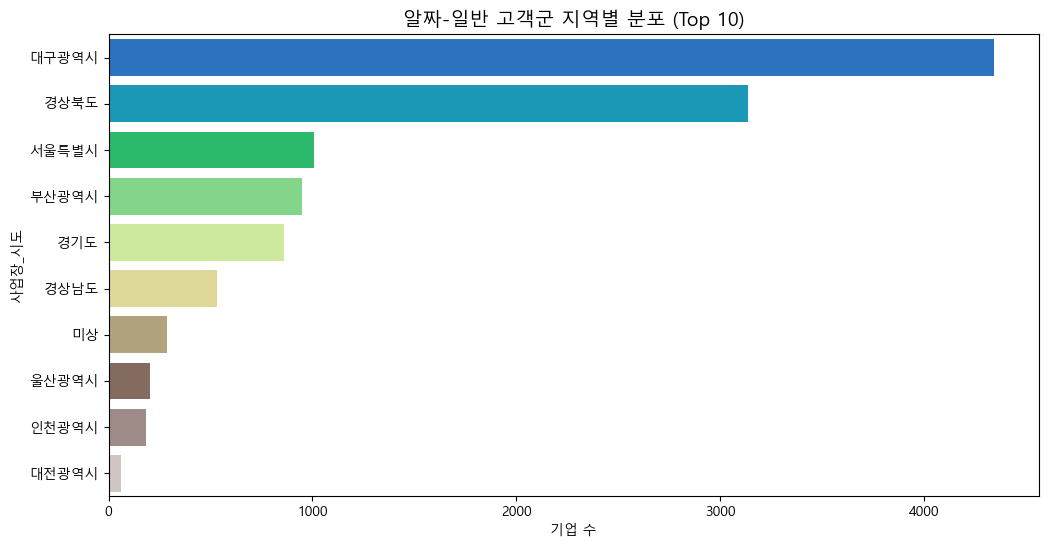

In [110]:
# 2. 지역별 분포 확인 (법인_고객소재지 컬럼 활용)
plt.figure(figsize=(12, 6))
# 소재지 정보가 '대구광역시', '경상북도' 등으로 되어있을 거야
region_counts = alzza_general['사업장_시도'].value_counts().head(10)

sns.barplot(x=region_counts.values, y=region_counts.index, palette='terrain')
plt.title('알짜-일반 고객군 지역별 분포 (Top 10)', fontsize=14)
plt.xlabel('기업 수')
plt.show()

# [인사이트] "대구/경북 비중이 압도적으로 높다면, 디지털 전환이 늦은 이유가 
# '지역 점포와의 유대감' 때문일 수 있습니다. 이럴 땐 강제 전환보다는 점포 중심의 디지털 케어가 정답입니다."

C:\Users\campus4D059\AppData\Local\Temp\ipykernel_10520\2604783935.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, palette='magma')


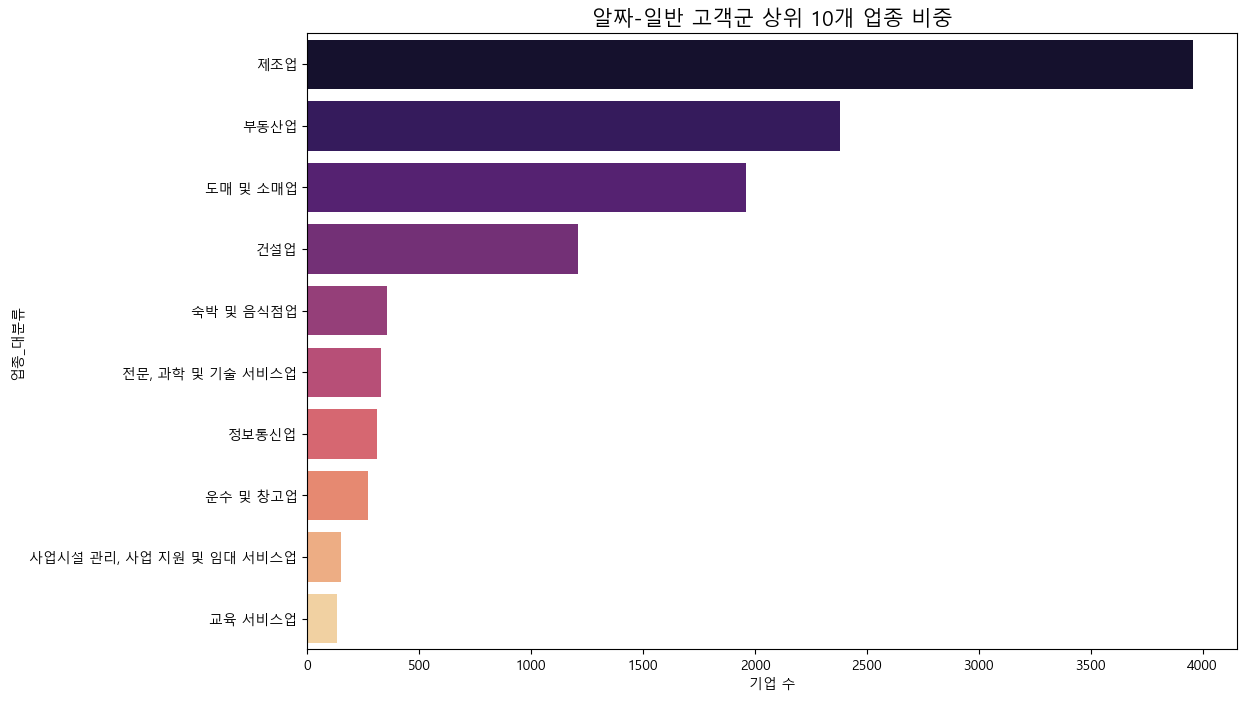

In [79]:
# 알짜- 일반 특징찾기(최종제언 활용)
# 업종별 집중도 분석 (Asset-Light & High-Margin 찾기)
import matplotlib.pyplot as plt
import seaborn as sns

# 알짜-일반 고객군 업종 분포 확인
plt.figure(figsize=(12, 8))
# 업종명 컬럼이 '업종'이나 '업종대분류'일 수 있으니 확인해줘!
top_industries = alzza_general['업종_대분류'].value_counts().head(10) 

sns.barplot(x=top_industries.values, y=top_industries.index, palette='magma')
plt.title('알짜-일반 고객군 상위 10개 업종 비중', fontsize=15)
plt.xlabel('기업 수')
plt.show()

# [인사이트] "일반 알짜는 서비스/도소매 비중이 높습니다. 이는 큰 설비 투자(자산) 없이도 
# 빈번한 결제와 수수료 수익을 창출하는 '실속형' 산업 구조임을 의미합니다."

In [92]:
aaa= alzza_general[alzza_general['총채널거래건수2']==1]

In [93]:
aaa.shape

(6202, 112)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

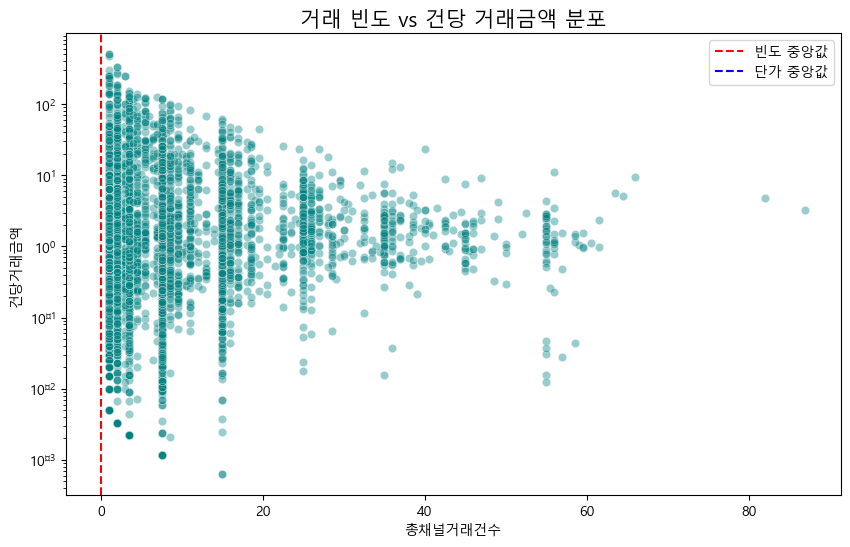

총채널거래건수 count
총채널거래건수2
1.0    6202
2.0    1263
3.0     722
4.0     129
4.5     679
Name: count, dtype: int64


In [107]:
# 거래패턴 분석 (건당 거래단가 vs 빈도)

# 건당 거래금액 산출 (Smoothing 적용)
alzza_general['건당거래금액'] = alzza_general['총채널거래금액'] / (alzza_general['총채널거래건수'] + 1)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=alzza_general, x='총채널거래건수', y='건당거래금액', alpha=0.4, color='teal')

# 중앙값 가이드라인 추가 (이 선을 기준으로 4분면 나눠서 설명하면 좋아!)
plt.axvline(alzza_general['총채널거래건수'].median(), color='red', linestyle='--', label='빈도 중앙값')
plt.axhline(alzza_general['건당거래금액'].median(), color='blue', linestyle='--', label='단가 중앙값')

plt.title('거래 빈도 vs 건당 거래금액 분포', fontsize=15)
plt.yscale('log') # 금액 편차가 크면 로그 스케일 추천!
plt.legend()
plt.show()

# [인사이트] "일반 알짜 중 다수는 거래 건수는 적지만 건당 거래 규모가 큰 '고단가형'입니다. 
# 이는 은행 입장에서 관리 리소스(Transaction cost) 대비 수익이 극대화되는 구간입니다."
print(f'총채널거래건수 count')
print(alzza_general['총채널거래건수2'].value_counts().sort_index().head(5))


In [102]:
digital_stats = cc.groupby('법인_고객등급')['디지털거래건수비중'].agg(['mean', 'median', 'max']).reindex(['우수', '일반'])

print("### [분석 1] 알짜 등급 내 고객등급별 디지털 채널 이용 현황 ###")
print(digital_stats)

### [분석 1] 알짜 등급 내 고객등급별 디지털 채널 이용 현황 ###
             mean  median  max
법인_고객등급                       
우수       0.432019     0.0  1.0
일반       0.359160     0.0  1.0


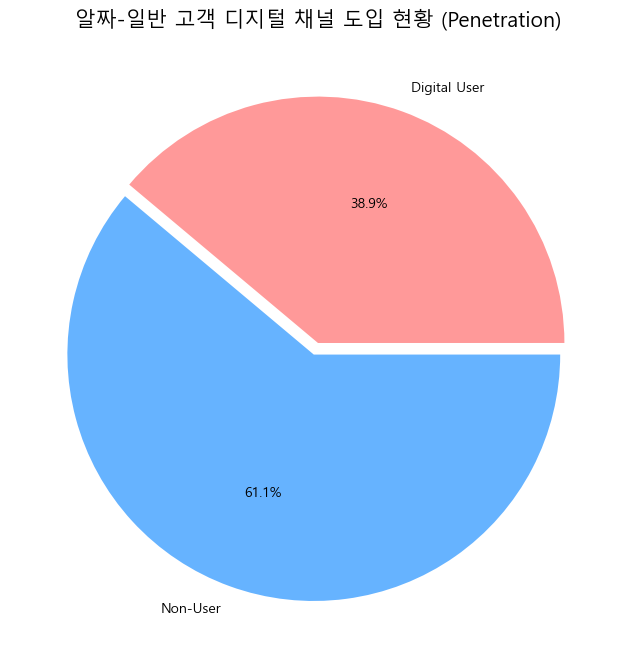

디지털사용여부
Non-User        7083
Digital User    4507
Name: count, dtype: int64


In [106]:
# 1. 디지털 사용 여부 컬럼 생성 (한 건이라도 있으면 'User', 없으면 'Non-User')
# '총디지털거래건수'가 0보다 크면 사용자로 간주
alzza_general['디지털사용여부'] = alzza_general['총디지털거래건수'].apply(lambda x: 'Digital User' if x > 0 else 'Non-User')

# 2. 비율 계산
usage_counts = alzza_general['디지털사용여부'].value_counts()

# 3. 파이 차트 시각화
plt.figure(figsize=(8, 8))
plt.pie(usage_counts, 
        labels=usage_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#66b3ff', '#ff9999'], 
        explode=(0.05, 0))

plt.title('알짜-일반 고객 디지털 채널 도입 현황 (Penetration)', fontsize=15)
plt.show()

print(usage_counts)

In [111]:
alzza_general['다양성점수'].describe()

count    11590.000000
mean         0.522908
std          0.139351
min          0.250000
25%          0.500000
50%          0.500000
75%          0.500000
max          0.750000
Name: 다양성점수, dtype: float64

C:\Users\campus4D059\AppData\Local\Temp\ipykernel_10520\631152407.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_usage.values, y=product_usage.index, palette='flare')


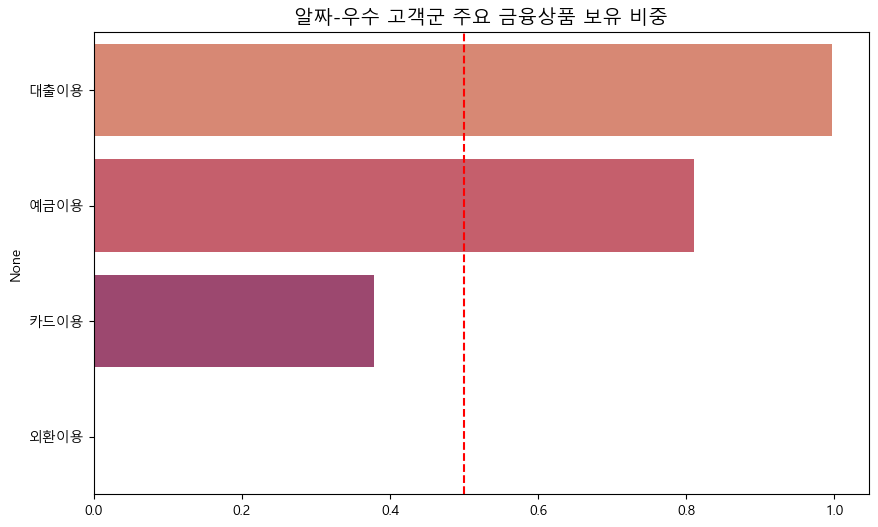

In [118]:
# 1. 알짜-우수 고객의 개별 상품 보유 현황 확인 (컬럼명은 주희 데이터에 맞춰 수정!)
# 보통 '보유여부'가 0/1로 되어있을 거야. 
product_cols = ['예금이용', '대출이용', '카드이용', '외환이용'] # 예시 컬럼들

# 상품별 보유 고객 비중 산출
product_usage = alzza_excellent[product_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=product_usage.values, y=product_usage.index, palette='flare')
plt.title('알짜-우수 고객군 주요 금융상품 보유 비중', fontsize=14)
plt.axvline(0.5, color='red', linestyle='--', label='보유율 50% 선')
plt.show()

# [인사이트] "보유율이 현저히 낮은 상품(예: 신탁)을 타겟으로 '상생 수수료 패키지'를 제안하십시오. 
# 기업은 자산관리 혜택을 받고, 은행은 비이자 수익원을 확보하는 윈윈 전략이 가능합니다."

C:\Users\campus4D059\AppData\Local\Temp\ipykernel_10520\2695637994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_usage.values, y=product_usage.index, palette='flare')


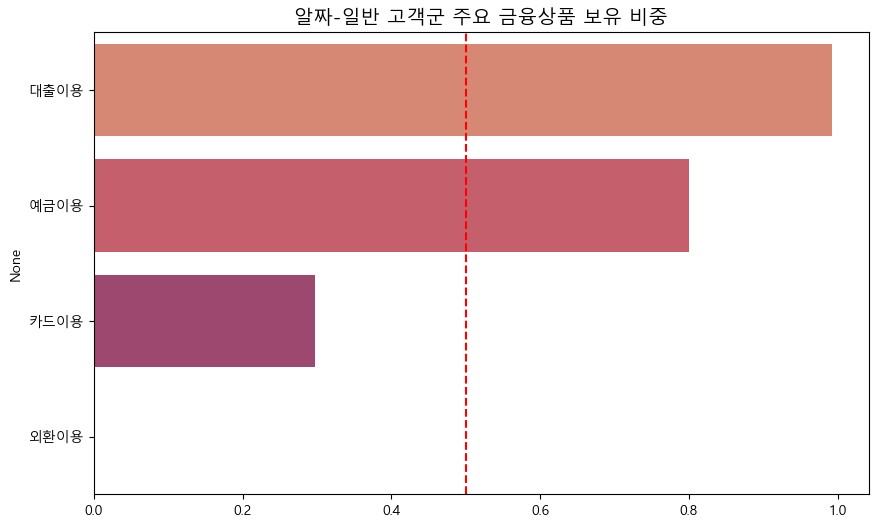

In [116]:
# 1. 알짜-일반 고객의 개별 상품 보유 현황 확인 (컬럼명은 주희 데이터에 맞춰 수정!)
# 보통 '보유여부'가 0/1로 되어있을 거야. 
product_cols = ['예금이용', '대출이용', '카드이용', '외환이용'] # 예시 컬럼들

# 상품별 보유 고객 비중 산출
product_usage = alzza_general[product_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=product_usage.values, y=product_usage.index, palette='flare')
plt.title('알짜-일반 고객군 주요 금융상품 보유 비중', fontsize=14)
plt.axvline(0.5, color='red', linestyle='--', label='보유율 50% 선')
plt.show()

# [인사이트] "보유율이 현저히 낮은 상품(예: 신탁)을 타겟으로 '상생 수수료 패키지'를 제안하십시오. 
# 기업은 자산관리 혜택을 받고, 은행은 비이자 수익원을 확보하는 윈윈 전략이 가능합니다."

C:\Users\campus4D059\AppData\Local\Temp\ipykernel_10520\2520461205.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=alzza_general, x='디지털사용여부', y='FPI', palette='Set3')


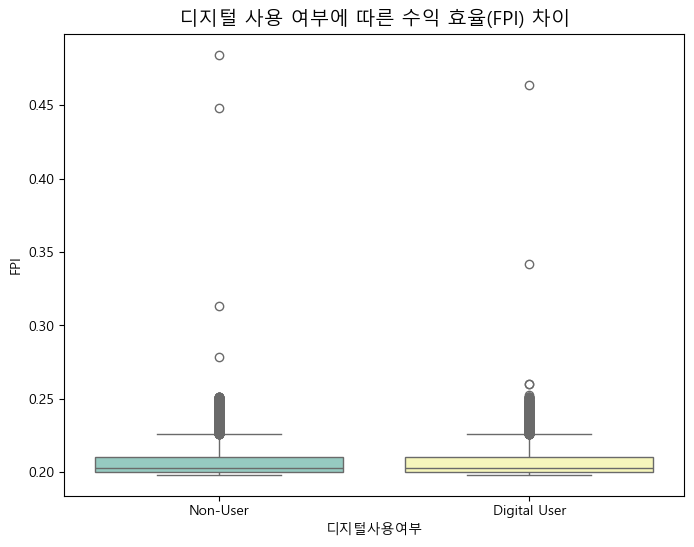

디지털 사용 여부에 따른 FPI 차이 검정 p-value: 0.7878


In [119]:
# 1. 디지털 사용 여부(이진)에 따른 수익 효율(FPI) 비교
plt.figure(figsize=(8, 6))
sns.boxplot(data=alzza_general, x='디지털사용여부', y='FPI', palette='Set3')
plt.title('디지털 사용 여부에 따른 수익 효율(FPI) 차이', fontsize=14)
plt.show()

# 2. 통계적 검정 (Mann-Whitney U)
user_fpi = alzza_general[alzza_general['디지털사용여부'] == 'Digital User']['FPI']
non_user_fpi = alzza_general[alzza_general['디지털사용여부'] == 'Non-User']['FPI']

u_stat, p_val = stats.mannwhitneyu(user_fpi, non_user_fpi)
print(f"디지털 사용 여부에 따른 FPI 차이 검정 p-value: {p_val:.4f}")

# [인사이트] "디지털 사용자의 FPI가 통계적으로 유의미하게 높다면(또는 비슷하다면), 
# 비활성 고객을 디지털로 온보딩시키는 것만으로도 운영 비용 절감을 통해 순수익이 증대됨을 입증합니다."

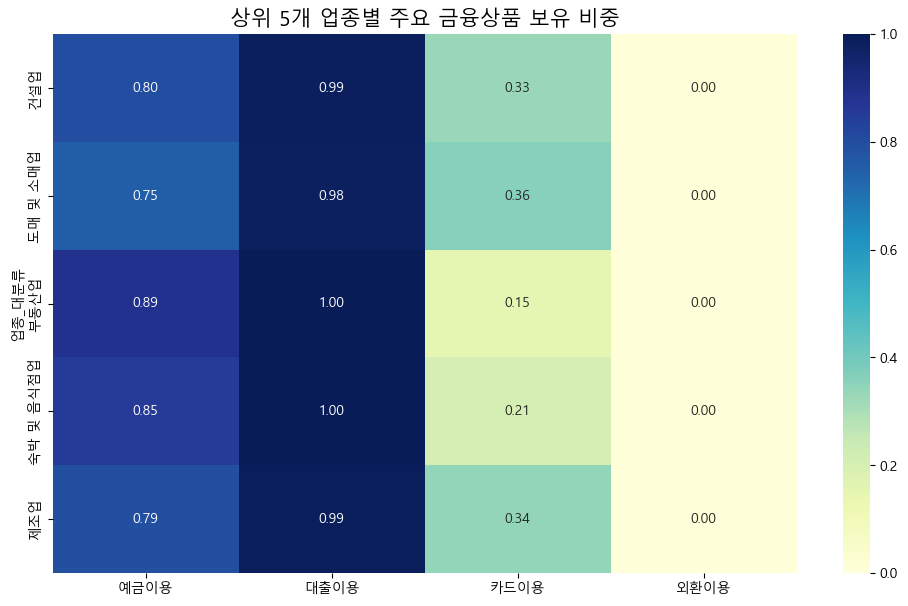

In [122]:
# 1. 상위 5개 업종 추출
top5_industries = alzza_general['업종_대분류'].value_counts().head(5).index.tolist()
alzza_top5 = alzza_general[alzza_general['업종_대분류'].isin(top5_industries)]

# 2. 분석할 상품 리스트 (주희 데이터 컬럼명에 맞춰 수정!)
product_cols = ['예금이용', '대출이용', '카드이용', '외환이용'] # 예시 컬럼들

# 3. 업종별 상품 보유 비중 계산
industry_product_ratio = alzza_top5.groupby('업종_대분류')[product_cols].mean()

# 4. 시각화 (Heatmap으로 보면 한눈에 들어와!)
import seaborn as sns
plt.figure(figsize=(12, 7))
sns.heatmap(industry_product_ratio, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('상위 5개 업종별 주요 금융상품 보유 비중', fontsize=15)
plt.show()

In [140]:
alzza_general['예금이용'].value_counts()

예금이용
1    9279
0    2311
Name: count, dtype: int64

In [141]:
asas= alzza_general[alzza_general['업종_대분류']=='금융 및 보험업']

In [146]:
print(alzza_general.shape)
print(asas.shape)

(11590, 114)
(62, 114)


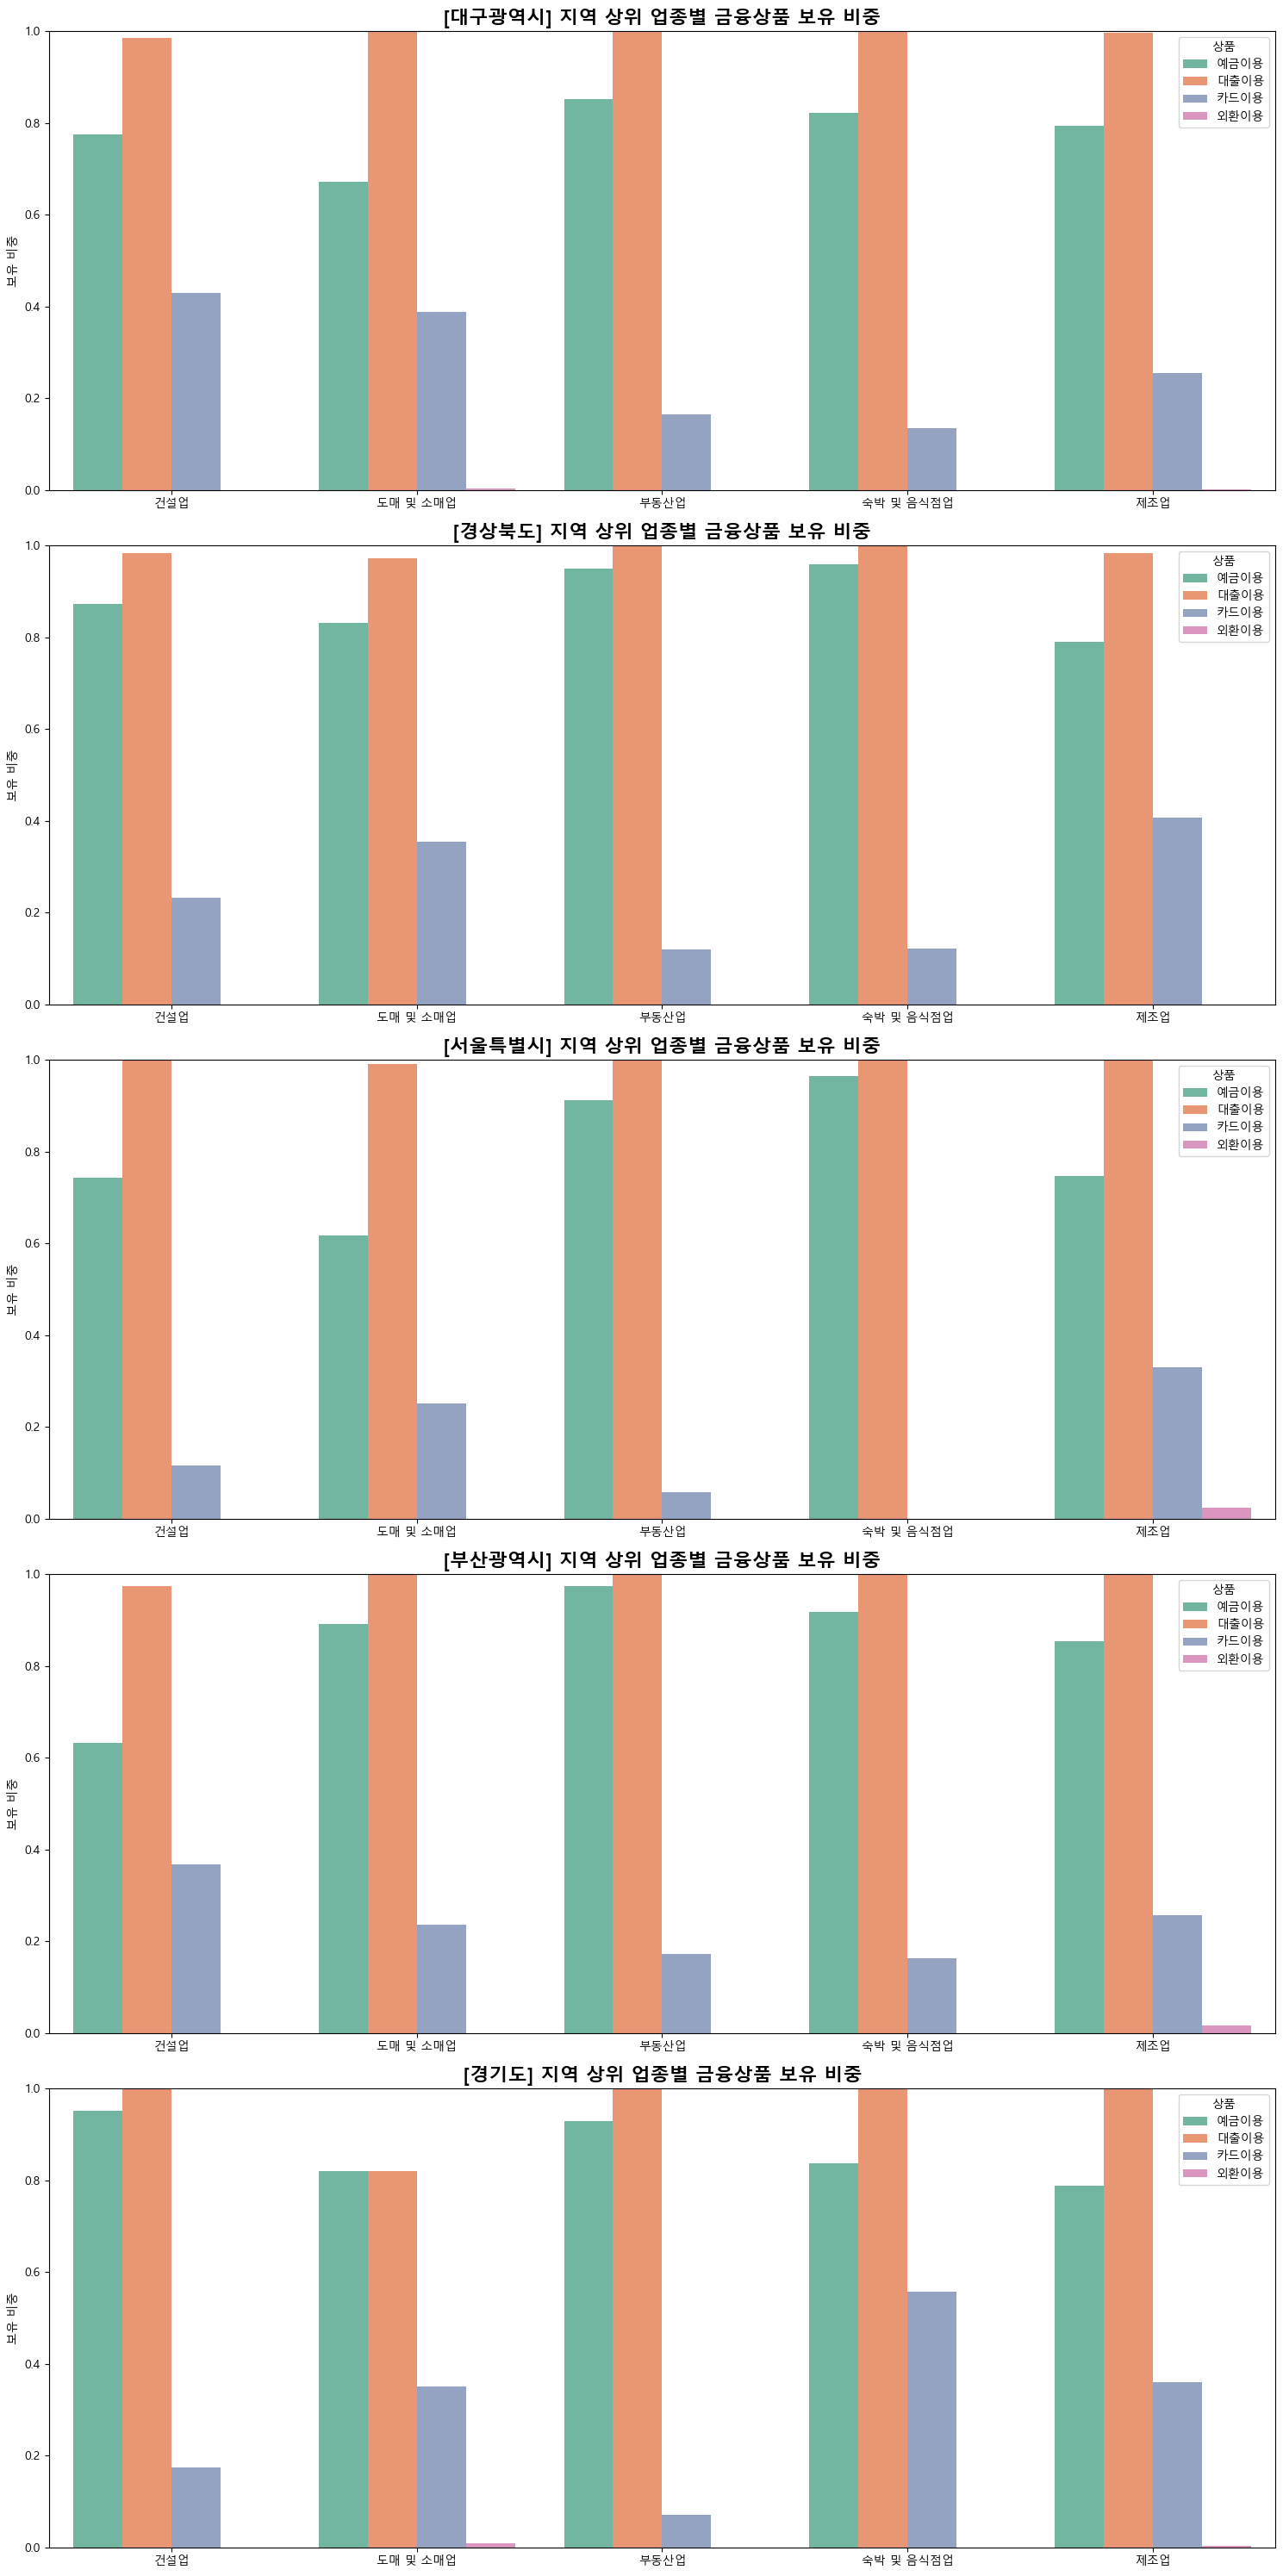

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 상위 5개 지역과 상위 5개 업종 추출
top5_regions = alzza_general['사업장_시도'].value_counts().head(5).index.tolist()
top5_industries = alzza_general['업종_대분류'].value_counts().head(5).index.tolist()

# 2. 분석할 상품 리스트
product_cols = ['예금이용', '대출이용', '카드이용', '외환이용'] # 예시 컬럼들

# 3. 그래프 그리기 (5개 지역별로 subplot 생성)
fig, axes = plt.subplots(5, 1, figsize=(15, 30)) # 지역이 5개니까 5행 1열

for i, region in enumerate(top5_regions):
    # 해당 지역 + 상위 5개 업종 데이터 필터링
    region_df = alzza_general[(alzza_general['사업장_시도'] == region) & 
                              (alzza_general['업종_대분류'].isin(top5_industries))]
    
    # 데이터 재구조화
    melted = region_df.groupby('업종_대분류')[product_cols].mean().reset_index().melt(id_vars='업종_대분류')
    
    # 그래프 시각화
    sns.barplot(data=melted, x='업종_대분류', y='value', hue='variable', ax=axes[i], palette='Set2')
    axes[i].set_title(f'[{region}] 지역 상위 업종별 금융상품 보유 비중', fontsize=16, fontweight='bold')
    axes[i].set_ylim(0, 1.0) # 비교를 위해 Y축 고정
    axes[i].legend(loc='upper right', title='상품')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('보유 비중')

plt.tight_layout()
plt.show()

In [131]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345553 entries, 0 to 347298
Data columns (total 91 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   기준년월           345553 non-null  int64  
 1   업종_대분류         345553 non-null  object 
 2   업종_중분류         345553 non-null  object 
 3   사업장_시도         345553 non-null  object 
 4   사업장_시군구        345553 non-null  object 
 5   법인_고객등급        345553 non-null  object 
 6   전담고객여부         345553 non-null  object 
 7   요구불예금잔액        345553 non-null  float64
 8   거치식예금잔액        345553 non-null  float64
 9   적립식예금잔액        345553 non-null  float64
 10  수익증권잔액         345553 non-null  float64
 11  신탁잔액           345553 non-null  float64
 12  퇴직연금잔액         345553 non-null  float64
 13  여신한도금액         345553 non-null  float64
 14  여신_운전자금대출잔액    345553 non-null  float64
 15  여신_시설자금대출잔액    345553 non-null  float64
 16  외환_수출실적금액      345553 non-null  float64
 17  외환_수입실적금액      345553 non-null  fl

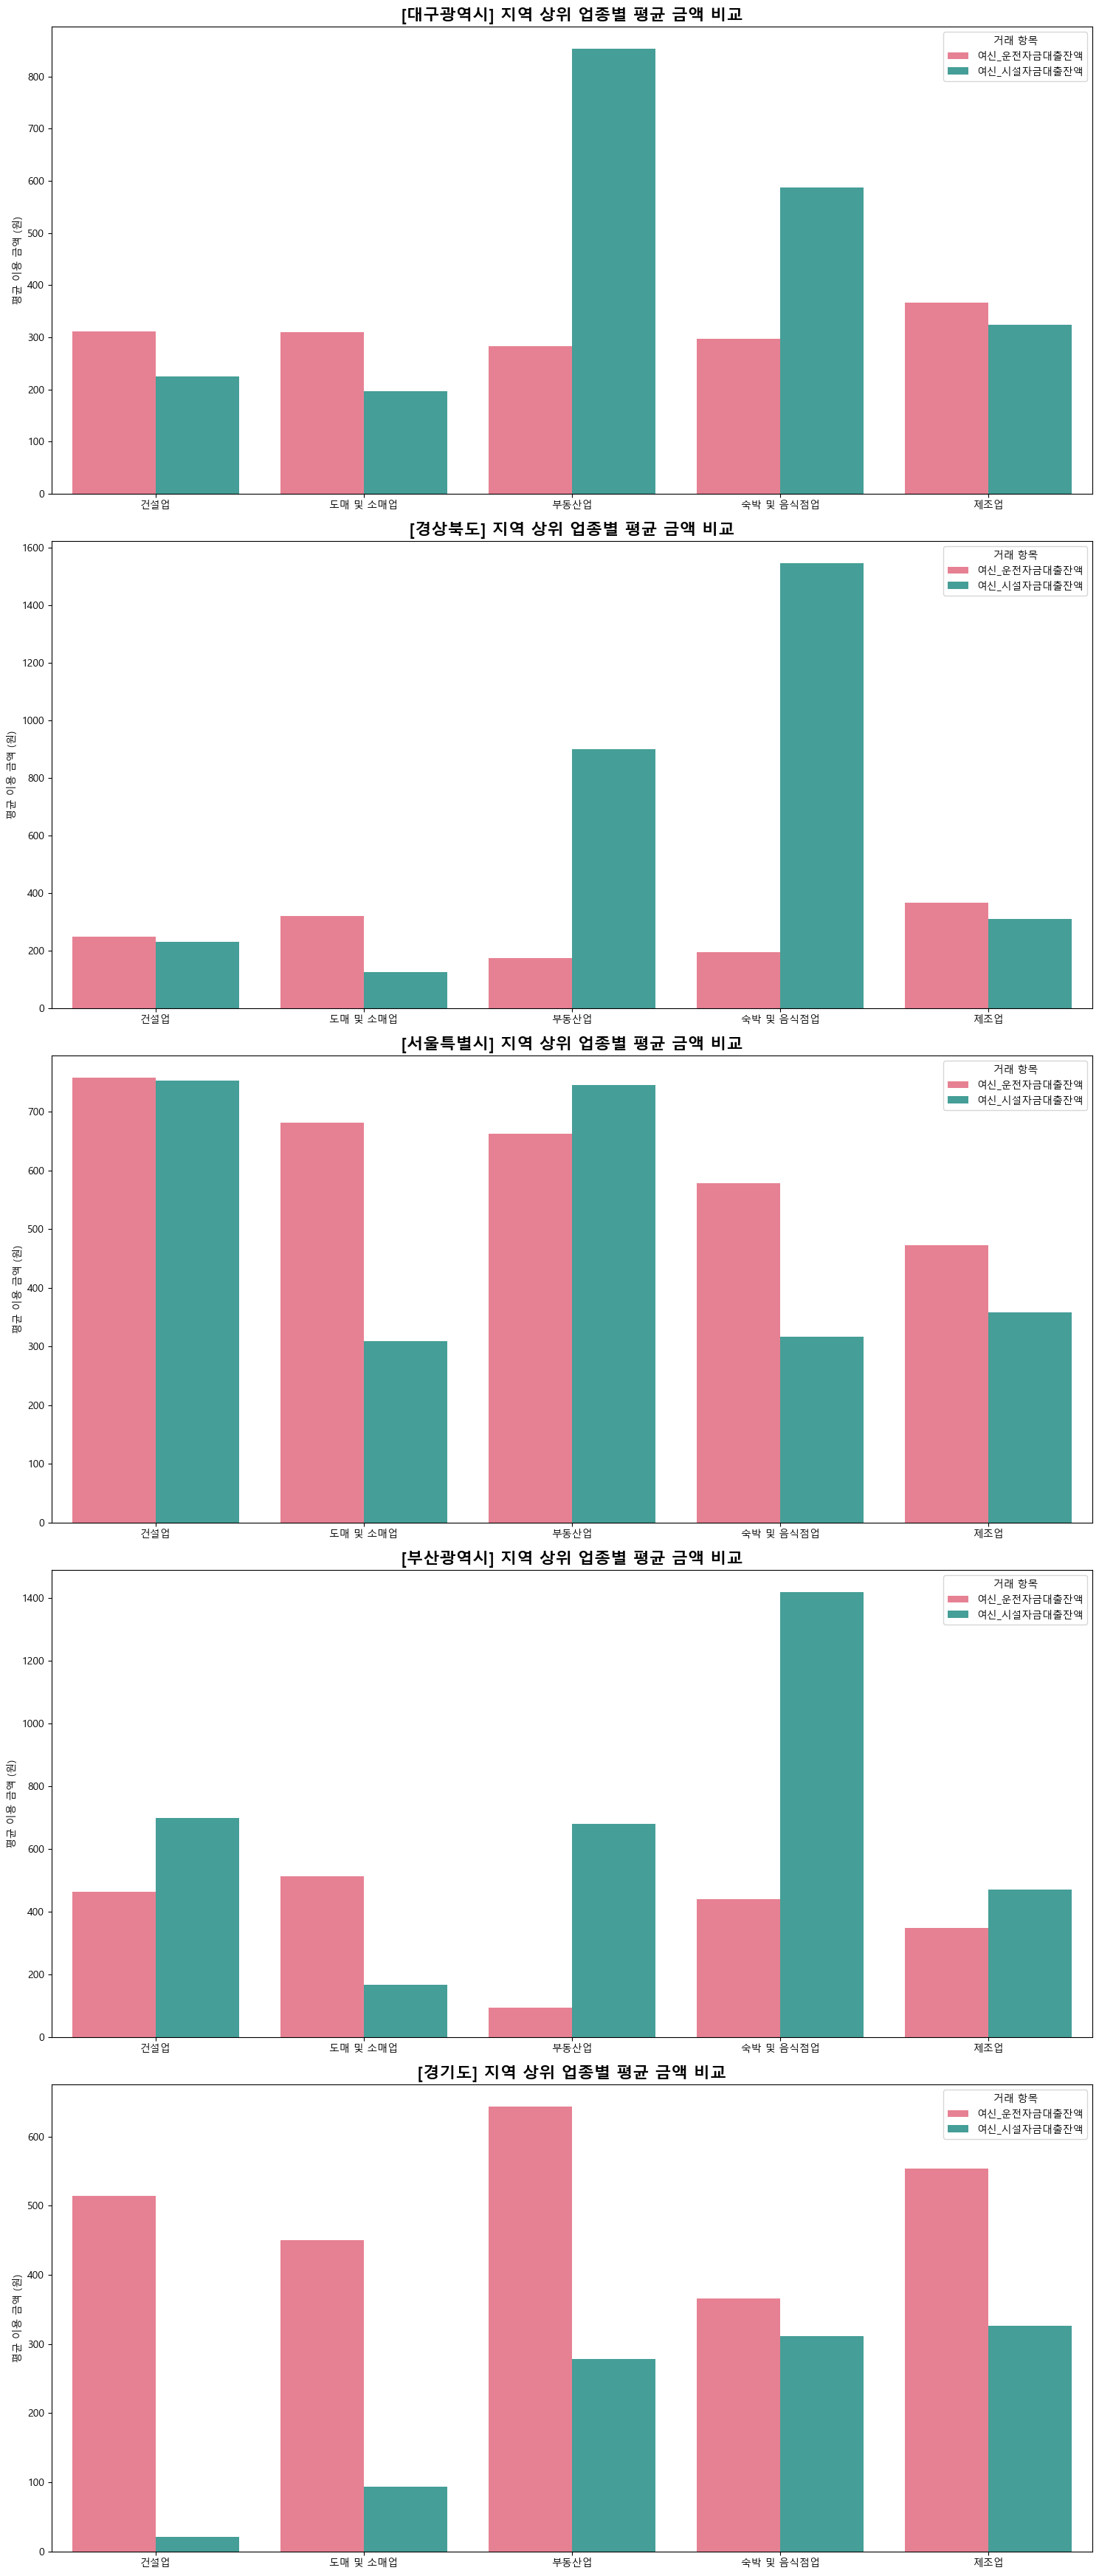

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 상위 5개 지역과 상위 5개 업종 추출 (기존 로직 유지)
top5_regions = alzza_general['사업장_시도'].value_counts().head(5).index.tolist()
top5_industries = alzza_general['업종_대분류'].value_counts().head(5).index.tolist()

# 2. 이용 '건수' 컬럼 리스트 (주희 데이터의 실제 '건수' 컬럼명으로 수정해!)
# 예: '총채널거래건수', '인터넷뱅킹거래건수', '카드이용건수' 등
cnt_cols = ['여신_운전자금대출잔액', '여신_시설자금대출잔액'] 

# 3. 그래프 그리기
fig, axes = plt.subplots(5, 1, figsize=(15, 35)) # 건수 차이를 보기 위해 높이 살짝 조절

for i, region in enumerate(top5_regions):
    region_df = alzza_general[(alzza_general['사업장_시도'] == region) & 
                              (alzza_general['업종_대분류'].isin(top5_industries))]
    
    # [핵심] 보유 여부가 아닌 '이용 건수'의 평균 산출
    melted = region_df.groupby('업종_대분류')[cnt_cols].mean().reset_index().melt(id_vars='업종_대분류')
    
    # 그래프 시각화
    sns.barplot(data=melted, x='업종_대분류', y='value', hue='variable', ax=axes[i], palette='husl')
    axes[i].set_title(f'[{region}] 지역 상위 업종별 평균 금액 비교', fontsize=16, fontweight='bold')
    
    # Y축은 데이터 최대값에 맞춰 자동 조절되게 설정 (고정 X)
    axes[i].set_ylabel('평균 이용 금액 (원)')
    axes[i].set_xlabel('')
    axes[i].legend(loc='upper right', title='거래 항목')

plt.tight_layout()
plt.show()

## 1. 기존 체계의 변별력 검정 (가설 1)
의문점: 기존 등급 체계가 고객의 실제 활동성과 수익성을 제대로 반영하고 있는가? 
가설: 기존 등급별 FAI(활동성), FPI(수익성) 분포는 적어도 하나 이상 다르다. 
변수 및 방법론: 기존 등급(최우수/우수/일반), FAI, FPI / Kruskal-Wallis H 검정 
결과: P-value < 0.001로 모든 등급 쌍이 유의미하게 다름을 확인했으나, 등급만으로는 고객 특성을 완전히 설명하기에 한계가 있음.

## 2. 기존 등급과 신규 사분면의 연관성 (가설 2)
의문점: 기존 등급 체계와 새롭게 정의한 4개 사분면 분류가 서로 독립적인가, 아니면 연관성이 있는가? 가설: 기존 기업등급과 사분면 등급은 독립이 아니다(연관성이 있다). 
변수 및 방법론: 기존 등급, 사분면 등급(Star/Cash Cow/Potential/Standard) / Chi-square Test 
결과: P-value < 0.001 (통계량 98191.24)로 연관성이 높음. 하지만 완전히 일치하지 않아 새 모델이 기존 등급을 효과적으로 보완함. 

## 3. 동일 등급 내 집단 차이 - 활동성 (가설 3-1)
의문점: 같은 등급(예: 우수) 안에서도 활동성(FAI)에 따라 유의미한 집단 차이가 존재하는가? 가설: 동일 등급 내부에서 사분면별 FAI 분포는 적어도 하나 이상 다르다. 
변수 및 방법론: 등급 내 4개 사분면, FAI / Kruskal-Wallis H 및 Dunn 사후검정 
결과: 우수(77,925), 일반(50,691), 최우수(33,913) 등 모든 등급에서 P-value < 0.001로 유의미한 차이 발생. 

## 4. 동일 등급 내 집단 차이 - 수익성 (가설 3-2)
의문점: 같은 등급 안에서도 수익성(FPI)에 따라 유의미한 집단 차이가 존재하는가? 가설: 동일 등급 내부에서 사분면별 FPI 분포는 적어도 하나 이상 다르다. 
변수 및 방법론: 등급 내 4개 사분면, FPI / Kruskal-Wallis H 및 Dunn 사후검정 
결과: 우수(78,268), 일반(86,613), 최우수(40,178) 등 모든 등급에서 P-value < 0.001로 유의미한 차이 도출. 

## 5. 활동성 축(X축)의 타당성 (연구질문 1)
의문점: 새로 정의한 활동성 지수(FAI)가 실제 고활동성과 저활동성 집단을 명확히 구분하는가? 가설: 활동성 고집단(스타+잠재)과 저집단(알짜+일반)의 FAI 분포는 실제 차이가 난다. 
변수 및 방법론: 활동성 고/저 집단, FAI Index / Mann-Whitney U Test 
결과: P-value < 0.001이며, 평균 FAI 차이가 1.8배(0.48 vs 0.27)로 나타나 모델의 분류 기준이 타당함을 입증. 

## 6. 수익성 축(Y축)의 타당성 (연구질문 2)
의문점: 새로 정의한 수익성 지수(FPI)가 실제 고수익성과 저수익성 집단을 유의하게 구분하는가? 가설: 수익성 고집단(스타+알짜)과 저집단(잠재+일반)의 FPI 분포는 실제 차이가 난다. 
변수 및 방법론: 수익성 고/저 집단, FPI Index / Mann-Whitney U Test 
결과: P-value < 0.001이며, 평균 FPI 차이가 약 8.6% 발생하여 수익성 축의 변별력을 확보. 

📊 [최종 해석] 여신(운전 vs 시설) 중심의 업종별 지원 전략
1. 제조업: "대구·경북의 심장, 시설 투자의 주역" (장기 지원)
현상: 대구, 경북 지역의 제조업은 운전자금보다 시설자금(하늘색) 비중이 상당히 높게 나타나고 있어.

해석: 이들은 공장을 새로 짓거나 기계를 들여오는 등 **'미래를 위한 투자'**를 하는 중이야. iM뱅크 입장에서는 아주 든든한 장기 고객이지.

제언: "제조업 알짜 기업에는 시설 투자를 적극 돕는 **'장기 저리 대출'**을 확대하고, 설비 도입에 따른 세무/회계 컨설팅을 함께 제공해 지역 기반 산업을 키워야 합니다."

2. 도소매업 & 부동산업: "현금 흐름의 동맥, 운전자금의 핵심" (유동성 지원)
현상: 도소매업과 부동산업은 시설자금보다 운전자금(보라색) 비중이 압도적이야.

해석: 이들은 물건을 사고팔거나 사업을 운영하는 데 필요한 '당장의 현금'이 중요한 업종이야.

제언: "도소매 알짜 기업에는 자금 회전율을 높여줄 수 있는 **'한도 대출(마이너스 통장)'**이나 **'결제 대금 할인 서비스'**를 통해 유동성을 적시에 공급해야 합니다."

3. 서울 지역의 특수성: "운전자금 중심의 비즈니스"
현상: 서울은 타 지역에 비해 전 업종에서 운전자금 수요가 더 뚜렷하게 보여.

해석: 서울 소재 알짜 중소기업들은 거대한 설비보다는 인건비, 마케팅, 임대료 등 '운영 비용' 비중이 큰 서비스나 유통 위주 비즈니스를 한다는 뜻이야.

제언: "서울 지역 알짜 고객에게는 시설자금보다는 **'운영비 절감형 법인카드'**나 '간편 운전자금 대출' 마케팅이 더 효과적입니다."

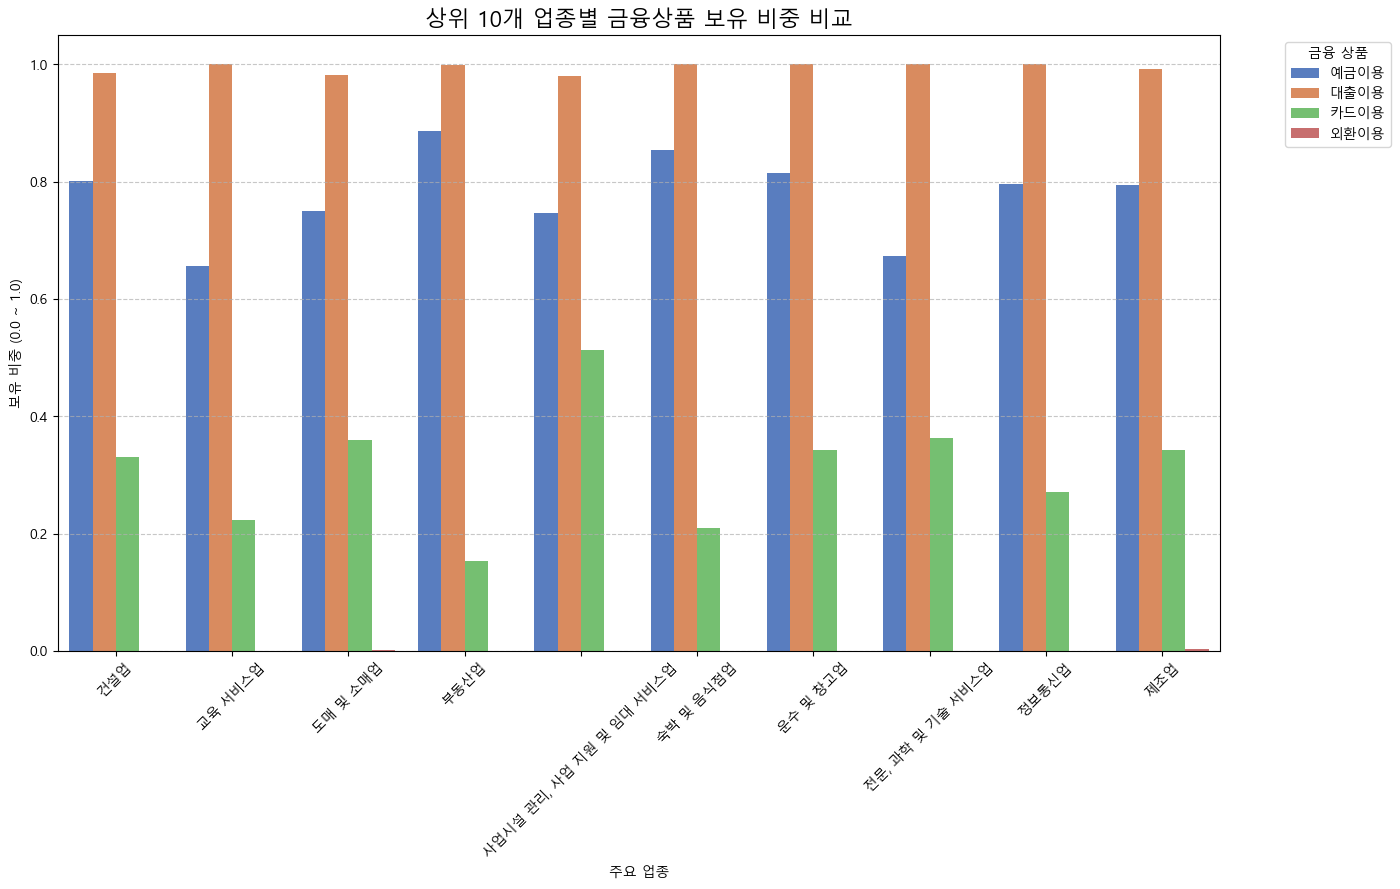

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 상위 5개 업종 추출 및 데이터 정리
top5_industries = alzza_general['업종_대분류'].value_counts().head(5).index.tolist()
alzza_top5 = alzza_general[alzza_general['업종_대분류'].isin(top5_industries)]

# 2. 분석할 상품 리스트 (보유 여부 0/1 컬럼들)
product_cols = ['예금이용', '대출이용', '카드이용', '외환이용'] # 예시 컬럼들

# 3. 데이터 재구조화 (시각화용)
# 업종별 평균을 구하고, melt를 통해 긴 형태(long-form)로 변환
melted_df = alzza_top5.groupby('업종_대분류')[product_cols].mean().reset_index().melt(id_vars='업종_대분류')

# 4. 막대그래프 시각화
plt.figure(figsize=(15, 8))
sns.barplot(data=melted_df, x='업종_대분류', y='value', hue='variable', palette='muted')

plt.title('상위 5개 업종별 금융상품 보유 비중 비교', fontsize=16)
plt.ylabel('보유 비중 (0.0 ~ 1.0)')
plt.xlabel('주요 업종')
plt.legend(title='금융 상품', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()